# Self-Pruning Neural Network on CIFAR-10 - PrunableMixer (v3)

**Tredence AI Engineering Internship - Case Study Submission**
*Author: Harshit Kulkarni*

A deep feed-forward classifier for CIFAR-10 in which **every** linear layer
is a custom `PrunableLinear` carrying a learnable per-weight sigmoid gate:

```
gates = sigmoid(gate_scores)           # shape == weight.shape, values in (0, 1)
W_eff = weight * gates                 # elementwise
y     = x @ W_eff.T + bias
```

Training minimises the prompt-specified joint objective

$$
\mathcal{L}
\;=\;
\mathcal{L}_{\mathrm{CE}}
\;+\;
\lambda \cdot
\underbrace{\sum_{l}\sum_{i,j}\sigma\!\bigl(g^{(l)}_{ij}\bigr)}_{\mathcal{L}_{\mathrm{sp}}:\ \text{L1 over all gate values}}
$$

A weight is declared *pruned* when its gate value falls below $10^{-2}$.

### Architecture: a PrunableLinear MLP-Mixer

We use an **MLP-Mixer** as the backbone (Tolstikhin et al. 2021) because it
is **100% feed-forward MLP** - every layer is literally `nn.Linear` - while
preserving spatial structure through patch tokens instead of discarding it
via flattening. That lifts the CIFAR-10 accuracy ceiling from ~62%
(flattened MLP) to ~80+ % while keeping the case-study prompt satisfied:

1. The only parameterised layers are `PrunableLinear`.
2. The entire network is feed-forward (no recurrence, no attention, no
   convolution).
3. The self-pruning mechanism is unchanged and applied uniformly to every
   `PrunableLinear`.

The Mixer adds one structural dimension to the analysis: sparsity can now
be reported **per path** - token-mixing MLPs (mix across patches) versus
channel-mixing MLPs (mix across channels) - revealing which kind of mixing
carries more redundancy.

### What v3 does that v2 could not

- ~57M prunable weights in a **12-block, depth-768, 4x4-patch** Mixer.
- Expected test accuracy ~**78 - 83%** (vs v2's ~67%).
- **Per-path sparsity analysis** (token-mix vs channel-mix).
- **100 epochs**, warmup 5 + ramp 5, Cutout + MixUp, AdamW, cosine, bf16,
  `torch.compile` max-autotune on Ampere+.
- Device-agnostic: detects CUDA and auto-tunes batch size, dataloader
  parallelism, bf16 autocast, TF32 matmul, and `torch.compile` from the
  detected GPU. CPU fallback.

### Deliverables

Every document is regenerated from `outputs/results_mlp.json` in the final
cell, so the numbers in every file always match the run:

- `README.md`
- `CASE_STUDY.md` + `CASE_STUDY.docx`
- `tredence_results_dashboard.xlsx`
- `figures/*.png` (8 figures incl. the required gate-distribution plot,
  the progressive-threshold curve, and the new per-path sparsity plot)


## 1. Environment check


In [1]:
_SHOW = True

import sys, platform, importlib

def _v(mod: str) -> str:
    try:
        m = importlib.import_module(mod)
        return getattr(m, "__version__", "?")
    except Exception:
        return "not installed"

import torch
print(f"python        : {sys.version.split()[0]}  ({platform.system()})")
print(f"torch         : {torch.__version__}")
print(f"torchvision   : {_v('torchvision')}")
print(f"numpy         : {_v('numpy')}")
print(f"matplotlib    : {_v('matplotlib')}")
print(f"openpyxl      : {_v('openpyxl')}   (optional, xlsx dashboard)")
print(f"python-docx   : {_v('docx')}       (optional, docx report)")

_cuda = torch.cuda.is_available()
print(f"CUDA available: {_cuda}")
if _cuda:
    _props = torch.cuda.get_device_properties(0)
    print(f"CUDA device   : {_props.name}")
    print(f"CUDA memory   : {_props.total_memory / 1024**3:.1f} GiB")
    print(f"CUDA version  : {torch.version.cuda}")
    print(f"SM capability : sm_{_props.major}{_props.minor}")
    if hasattr(torch.cuda, "is_bf16_supported"):
        print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")

python        : 3.12.11  (Linux)
torch         : 2.8.0+cu128
torchvision   : 0.23.0+cu128
numpy         : 1.26.4
matplotlib    : 3.8.2
openpyxl      : not installed   (optional, xlsx dashboard)
python-docx   : not installed       (optional, docx report)
CUDA available: True
CUDA device   : NVIDIA H100 80GB HBM3
CUDA memory   : 79.1 GiB
CUDA version  : 12.8
SM capability : sm_90
bf16 supported: True


## 2. Master configuration

Single `Config` dataclass. The **architecture and training recipe are fixed
across all devices** - only batch size, dataloader parallelism, `bf16`,
`torch.compile`, and TF32 vary - so numbers are reproducible regardless of
where the code runs.


In [2]:
from pathlib import Path
from dataclasses import dataclass, field, asdict
import os, random
import numpy as np
import torch


@dataclass
class Config:
    # ---------- reproducibility ----------
    seed       : int = 42

    # ---------- paths (relative only) ----------
    data_root  : Path = field(default_factory=lambda: Path("./data"))
    ckpt_dir   : Path = field(default_factory=lambda: Path("./checkpoints"))
    fig_dir    : Path = field(default_factory=lambda: Path("./figures"))
    out_dir    : Path = field(default_factory=lambda: Path("./outputs"))

    # ---------- PrunableMixer architecture ----------
    image_size      : int = 32
    image_channels  : int = 3
    patch_size      : int = 4        # -> 8 x 8 = 64 tokens of 48-D each
    mixer_dim       : int = 768      # embedding dim (per token)
    mixer_depth     : int = 12       # number of mixer blocks
    token_hidden    : int = 256      # hidden dim in the token-mixing MLP
    channel_hidden  : int = 3072     # hidden dim in the channel-mixing MLP
    num_classes     : int = 10
    dropout         : float = 0.1

    # ---------- gate mechanism ----------
    gate_init       : float = -2.0           # sigmoid(-2) = 0.1192
    prune_threshold : float = 1e-2

    # ---------- optimization (AdamW) ----------
    lr_weights      : float = 1e-3
    lr_gates        : float = 1e-2
    weight_decay    : float = 5e-4           # weights only; gates wd = 0
    grad_clip       : float = 1.0
    label_smoothing : float = 0.1

    # ---------- regularisation / augmentation ----------
    use_cutout      : bool  = True
    cutout_p        : float = 0.25
    cutout_scale    : tuple = (0.02, 0.2)
    use_mixup       : bool  = True
    mixup_alpha     : float = 0.2

    # ---------- schedule ----------
    epochs          : int   = 100
    warmup_epochs   : int   = 5              # pure CE (lambda = 0)
    ramp_epochs     : int   = 5              # linear 0 -> target lambda

    # ---------- dataloader (auto-tuned) ----------
    batch_size      : int   = 256
    num_workers     : int   = 0
    pin_memory      : bool  = False
    prefetch_factor : int   = 2

    # ---------- sparsity sweep ----------
    # Calibrated for ~57M gates (L1-sum form).
    lambda_values   : tuple = (1e-7, 1e-6, 1e-5)

    # ---------- performance flags (auto-tuned) ----------
    use_amp         : bool  = False
    use_compile     : bool  = False
    compile_mode    : str   = "reduce-overhead"
    use_tf32        : bool  = False


cfg = Config()

# --- auto-tune per device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_MEM_GIB = 0.0
if DEVICE.type == "cuda":
    _props = torch.cuda.get_device_properties(0)
    GPU_MEM_GIB = _props.total_memory / 1024**3
    _sm = _props.major * 10 + _props.minor

    # Mixer intermediates are memory-hungry (B, 64, 3072); be a bit less
    # generous on batch size than v2. H100-80 handles 1024 comfortably.
    if GPU_MEM_GIB >= 60:                       # H100-80 / A100-80
        cfg.batch_size, cfg.num_workers = 1024, 8
    elif GPU_MEM_GIB >= 30:                     # A100-40 / L40
        cfg.batch_size, cfg.num_workers =  512, 8
    elif GPU_MEM_GIB >= 16:                     # L4 / A10 / RTX 4080+
        cfg.batch_size, cfg.num_workers =  256, 4
    elif GPU_MEM_GIB >= 10:                     # T4-16 / 3080 / 5070 Ti
        cfg.batch_size, cfg.num_workers =  128, 4
    else:
        cfg.batch_size, cfg.num_workers =   64, 2

    cfg.pin_memory      = True
    cfg.prefetch_factor = 4
    cfg.use_amp         = (torch.cuda.is_bf16_supported()
                           if hasattr(torch.cuda, "is_bf16_supported") else False)
    cfg.use_compile     = hasattr(torch, "compile")
    cfg.compile_mode    = "max-autotune" if _sm >= 80 else "reduce-overhead"
    cfg.use_tf32        = (_sm >= 80)
else:
    cfg.batch_size      = 64
    cfg.num_workers     = 0
    cfg.pin_memory      = False
    cfg.prefetch_factor = 2
    cfg.use_amp         = False
    cfg.use_compile     = False
    cfg.use_tf32        = False


# --- global backend flags (safe on every device) ---
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    if cfg.use_tf32:
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cuda.matmul.allow_tf32 = True
        if hasattr(torch, "set_float32_matmul_precision"):
            torch.set_float32_matmul_precision("high")


# --- quiet torch.compile / dynamo logs (informational spam on some stacks) ---
import logging
logging.getLogger("torch._inductor").setLevel(logging.ERROR)
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)
logging.getLogger("torch._inductor.select_algorithm").setLevel(logging.CRITICAL)


# --- output directories (relative) ---
for p in (cfg.data_root, cfg.ckpt_dir, cfg.fig_dir, cfg.out_dir):
    p.mkdir(parents=True, exist_ok=True)


# --- seed everything ---
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)


print(f"device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu             : {torch.cuda.get_device_name(0)}  "
          f"(sm_{_props.major}{_props.minor}, {GPU_MEM_GIB:.1f} GiB)")
print(f"batch_size      : {cfg.batch_size}")
print(f"num_workers     : {cfg.num_workers}  (prefetch_factor={cfg.prefetch_factor})")
print(f"pin_memory      : {cfg.pin_memory}")
print(f"bf16 autocast   : {cfg.use_amp}")
print(f"torch.compile   : {cfg.use_compile}  (mode='{cfg.compile_mode}')")
print(f"TF32 matmul     : {cfg.use_tf32}")
print(f"epochs          : {cfg.epochs}  (warmup={cfg.warmup_epochs}, ramp={cfg.ramp_epochs})")
print(f"lr (weights)    : {cfg.lr_weights}     (AdamW, wd={cfg.weight_decay})")
print(f"lr (gate_scores): {cfg.lr_gates}     (AdamW, wd=0)")
print(f"gate_init       : {cfg.gate_init}  -> sigmoid = {1/(1+np.exp(-cfg.gate_init)):.4f}")
print(f"prune threshold : {cfg.prune_threshold}")
print(f"lambda values   : {list(cfg.lambda_values)}  (L1 on sum of gate values)")
_n_tokens = (cfg.image_size // cfg.patch_size) ** 2
print(f"mixer           : depth={cfg.mixer_depth}, dim={cfg.mixer_dim}, "
      f"patch={cfg.patch_size}x{cfg.patch_size} -> {_n_tokens} tokens")
print(f"token hidden    : {cfg.token_hidden}   channel hidden: {cfg.channel_hidden}")
print(f"Cutout          : {cfg.use_cutout} (p={cfg.cutout_p}, scale={cfg.cutout_scale})")
print(f"MixUp           : {cfg.use_mixup}  (alpha={cfg.mixup_alpha})")

device          : cuda
gpu             : NVIDIA H100 80GB HBM3  (sm_90, 79.1 GiB)
batch_size      : 1024
num_workers     : 8  (prefetch_factor=4)
pin_memory      : True
bf16 autocast   : True
torch.compile   : True  (mode='max-autotune')
TF32 matmul     : True
epochs          : 100  (warmup=5, ramp=5)
lr (weights)    : 0.001     (AdamW, wd=0.0005)
lr (gate_scores): 0.01     (AdamW, wd=0)
gate_init       : -2.0  -> sigmoid = 0.1192
prune threshold : 0.01
lambda values   : [1e-07, 1e-06, 1e-05]  (L1 on sum of gate values)
mixer           : depth=12, dim=768, patch=4x4 -> 64 tokens
token hidden    : 256   channel hidden: 3072
Cutout          : True (p=0.25, scale=(0.02, 0.2))
MixUp           : True  (alpha=0.2)


In [3]:
cfg.use_compile = False
cfg.compile_mode = "reduce-overhead"

import logging, os
os.environ["TORCH_LOGS"] = ""
logging.getLogger("torch._inductor").setLevel(logging.CRITICAL)
logging.getLogger("torch._dynamo").setLevel(logging.CRITICAL)

print(f"compile disabled  | bf16 autocast still on: {cfg.use_amp}  | TF32 still on: {cfg.use_tf32}")

compile disabled  | bf16 autocast still on: True  | TF32 still on: True


## 3. CIFAR-10 data pipeline

- Standard CIFAR-10 mean/std normalisation.
- `RandomCrop(32, pad=4)` + `RandomHorizontalFlip` + `ColorJitter(0.1)`.
- **Cutout** via `RandomErasing` (p = 0.25, post-Normalise).
- **MixUp** (alpha = 0.2) is applied on-the-fly inside the training loop
  (not as a transform), so it lives in `train_one_epoch`.

Images are kept in `(3, 32, 32)` layout - the `PrunableMixer` does its own
patchification inside `forward`.


In [4]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader


_CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
_CIFAR_STD  = (0.2470, 0.2435, 0.2616)

_train_ops = [
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
    T.Normalize(_CIFAR_MEAN, _CIFAR_STD),
]
if cfg.use_cutout:
    _train_ops.append(T.RandomErasing(p=cfg.cutout_p, scale=cfg.cutout_scale))

train_tf = T.Compose(_train_ops)
test_tf  = T.Compose([
    T.ToTensor(),
    T.Normalize(_CIFAR_MEAN, _CIFAR_STD),
])

train_set = torchvision.datasets.CIFAR10(
    root=str(cfg.data_root), train=True,  download=True, transform=train_tf,
)
test_set = torchvision.datasets.CIFAR10(
    root=str(cfg.data_root), train=False, download=True, transform=test_tf,
)

_loader_kwargs = dict(
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
if cfg.num_workers > 0:
    _loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

train_loader = DataLoader(
    train_set, batch_size=cfg.batch_size, shuffle=True, drop_last=False,
    **_loader_kwargs,
)
test_loader = DataLoader(
    test_set, batch_size=max(1024, cfg.batch_size), shuffle=False,
    **_loader_kwargs,
)

x_sample, y_sample = next(iter(train_loader))
print(f"train : {len(train_set):,} images   test : {len(test_set):,} images")
print(f"batch : {tuple(x_sample.shape)}   labels : {tuple(y_sample.shape)}")
print(f"class : {train_set.classes}")

train : 50,000 images   test : 10,000 images
batch : (1024, 3, 32, 32)   labels : (1024,)
class : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. `PrunableLinear` - the core of the case study

Exact signature requested by the prompt: `PrunableLinear(in_features, out_features)`.
Carries two equal-shaped trainable tensors:

- `weight` - Kaiming-uniform init (fan_in, ReLU).
- `gate_scores` - initialised at a constant so `sigmoid(gate_scores)` sits
  just above the pruning threshold. Close enough that sparsity pressure can
  push gates through the threshold; not so closed that $\sigma'$ attenuation
  disables the gate gradient before training begins.

Works identically whether the input is a 2-D `(B, in_features)` tensor (a
dense MLP layer) or a 3-D `(B, N, in_features)` tensor (a Mixer block
mixing patches or channels). `torch.nn.functional.linear` handles both by
broadcasting the last dimension, which is precisely the contract we need.


In [5]:
import torch.nn as nn
import torch.nn.functional as F


class PrunableLinear(nn.Module):
    """
    Fully-connected layer with a learnable per-weight sigmoid gate.

        gates = sigmoid(gate_scores)     # same shape as weight, in (0, 1)
        W_eff = weight * gates           # elementwise
        y     = x @ W_eff.T + bias

    A weight is counted as PRUNED when its gate value is strictly below
    `threshold` (default 1e-2).
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        gate_init: float = -2.0,
    ) -> None:
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.gate_scores = nn.Parameter(torch.full_like(self.weight, float(gate_init)))

        nn.init.kaiming_uniform_(self.weight, a=0.0, mode="fan_in",
                                 nonlinearity="relu")

    def gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores)

    def pruned_weight(self) -> torch.Tensor:
        return self.weight * self.gates()

    def sparsity(self, threshold: float = 1e-2) -> float:
        with torch.no_grad():
            return (self.gates() < threshold).float().mean().item()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.linear(x, self.pruned_weight(), self.bias)

    def extra_repr(self) -> str:
        g0 = float(self.gate_scores.data.flatten()[0].item())
        return (f"in_features={self.in_features}, out_features={self.out_features}, "
                f"bias={self.bias is not None}, gate_init={g0:.2f}")


# ---------- sanity: gradient flow + initial state ----------
_demo = PrunableLinear(16, 8, gate_init=cfg.gate_init).to(DEVICE)
_x = torch.randn(4, 16, device=DEVICE)
_y = _demo(_x); _y.pow(2).sum().backward()

print(f"initial gate value (sigma(gate_init))  : {_demo.gates()[0, 0].item():.4f}")
print(f"initial sparsity @ threshold={cfg.prune_threshold}  : {_demo.sparsity(cfg.prune_threshold)*100:.2f}%")
print(f"grad to weight         : {_demo.weight.grad is not None}   max|g| = {_demo.weight.grad.abs().max().item():.3e}")
print(f"grad to gate_scores    : {_demo.gate_scores.grad is not None}   max|g| = {_demo.gate_scores.grad.abs().max().item():.3e}")

# also verify on a 3-D input, which is what the Mixer will feed
_demo2 = PrunableLinear(16, 8, gate_init=cfg.gate_init).to(DEVICE)
_x3 = torch.randn(4, 5, 16, device=DEVICE)
_y3 = _demo2(_x3)
print(f"forward (B, N, F) shape: {tuple(_x3.shape)} -> {tuple(_y3.shape)}  OK")

del _demo, _x, _y, _demo2, _x3, _y3

initial gate value (sigma(gate_init))  : 0.1192
initial sparsity @ threshold=0.01  : 0.00%
grad to weight         : True   max|g| = 3.754e-01
grad to gate_scores    : True   max|g| = 1.949e-01
forward (B, N, F) shape: (4, 5, 16) -> (4, 5, 8)  OK


## 5. `PrunableMixer` - architecture

An MLP-Mixer (Tolstikhin et al. 2021) built entirely from `PrunableLinear`
layers. Each block contains two residual paths:

**Token-mixing path** (mixes across patches, per channel):
```
y <- transpose(LayerNorm(x))           # (B, D, N)
y <- PrunableLinear(N -> token_hidden) ; GELU ; Dropout
y <- PrunableLinear(token_hidden -> N)
x <- x + transpose(y)                  # (B, N, D)
```

**Channel-mixing path** (mixes across channels, per patch):
```
y <- LayerNorm(x)                      # (B, N, D)
y <- PrunableLinear(D -> channel_hidden) ; GELU ; Dropout
y <- PrunableLinear(channel_hidden -> D)
x <- x + y
```

Input pathway: `image (B, 3, 32, 32) -> patches (B, 64, 48) -> embed
(B, 64, D) -> N x MixerBlock -> mean over patches -> classifier -> (B, 10)`.

**Both** MLP types are `PrunableLinear`, so the prompt's pruning mechanism
applies uniformly across the entire model. The spatial structure is
preserved through patch tokenisation (not discarded by flattening), which
is the single biggest reason this architecture clears 80% on CIFAR-10
where a flattened MLP tops out near 62%.


In [6]:
class MlpBlock(nn.Module):
    """Two PrunableLinear layers with GELU, for use as token- or channel-mix."""
    def __init__(self, in_dim: int, hidden_dim: int, dropout: float, gate_init: float):
        super().__init__()
        self.fc1 = PrunableLinear(in_dim, hidden_dim, gate_init=gate_init)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = PrunableLinear(hidden_dim, in_dim, gate_init=gate_init)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop2(self.fc2(self.drop1(self.act(self.fc1(x)))))


class MixerBlock(nn.Module):
    def __init__(
        self, num_tokens: int, dim: int,
        token_hidden: int, channel_hidden: int,
        dropout: float, gate_init: float,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.token_mlp = MlpBlock(num_tokens, token_hidden, dropout, gate_init)
        self.norm2 = nn.LayerNorm(dim)
        self.channel_mlp = MlpBlock(dim, channel_hidden, dropout, gate_init)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Token-mixing: transpose to (B, D, N), apply MLP across N, transpose back.
        y = self.norm1(x).transpose(1, 2)   # (B, D, N)
        y = self.token_mlp(y).transpose(1, 2)
        x = x + y
        # Channel-mixing: MLP across D directly on (B, N, D).
        y = self.channel_mlp(self.norm2(x))
        x = x + y
        return x


class PrunableMixer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        assert cfg.image_size % cfg.patch_size == 0, \
            "image_size must be divisible by patch_size"
        self.patch_size = cfg.patch_size
        self.image_size = cfg.image_size
        self.channels   = cfg.image_channels
        self.num_tokens = (cfg.image_size // cfg.patch_size) ** 2
        patch_dim = cfg.image_channels * cfg.patch_size * cfg.patch_size

        self.patch_embed = PrunableLinear(patch_dim, cfg.mixer_dim,
                                          gate_init=cfg.gate_init)
        self.blocks = nn.ModuleList([
            MixerBlock(
                num_tokens=self.num_tokens,
                dim=cfg.mixer_dim,
                token_hidden=cfg.token_hidden,
                channel_hidden=cfg.channel_hidden,
                dropout=cfg.dropout,
                gate_init=cfg.gate_init,
            )
            for _ in range(cfg.mixer_depth)
        ])
        self.norm       = nn.LayerNorm(cfg.mixer_dim)
        self.classifier = PrunableLinear(cfg.mixer_dim, cfg.num_classes,
                                         gate_init=cfg.gate_init)

    def _patchify(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) -> (B, N, C*P*P)."""
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.view(B, C, H // p, p, W // p, p)         # (B, C, H/p, p, W/p, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()   # (B, H/p, W/p, C, p, p)
        x = x.view(B, self.num_tokens, C * p * p)      # (B, N, C*P*P)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Accept either (B, C, H, W) or pre-flattened (B, C*H*W).
        if x.dim() == 2:
            x = x.view(-1, self.channels, self.image_size, self.image_size)
        x = self._patchify(x)                 # (B, N, patch_dim)
        x = self.patch_embed(x)               # (B, N, D)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)                     # (B, D)
        return self.classifier(x)             # (B, num_classes)

    def prunable_layers(self) -> list[PrunableLinear]:
        return [m for m in self.modules() if isinstance(m, PrunableLinear)]


# ---- annotate each PrunableLinear with its path (for per-path analysis) ----
def annotate_paths(net: "PrunableMixer") -> None:
    """Tag every PrunableLinear with a `._path` attribute:
       'patch_embed' | 'token_mix' | 'channel_mix' | 'classifier'."""
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            m._path = "other"

    net.patch_embed._path = "patch_embed"
    net.classifier._path  = "classifier"
    for blk in net.blocks:
        for pl in blk.token_mlp.modules():
            if isinstance(pl, PrunableLinear):
                pl._path = "token_mix"
        for pl in blk.channel_mlp.modules():
            if isinstance(pl, PrunableLinear):
                pl._path = "channel_mix"


_probe = PrunableMixer(cfg).to(DEVICE)
annotate_paths(_probe)
print(_probe)

_weight_p = sum(m.weight.numel()      for m in _probe.prunable_layers())
_gate_p   = sum(m.gate_scores.numel() for m in _probe.prunable_layers())
_total_p  = sum(p.numel() for p in _probe.parameters())
_n_prun   = len(_probe.prunable_layers())

print(f"\nprunable layers  : {_n_prun}")
print(f"weight params    : {_weight_p:,}")
print(f"gate params      : {_gate_p:,}  (one gate per weight)")
print(f"total params     : {_total_p:,}")
print(f"dense size (fp32): {_total_p * 4 / 1024**2:.1f} MB")

# per-path parameter census
from collections import Counter
_path_counts = Counter()
_path_gates  = Counter()
for m in _probe.prunable_layers():
    _path_counts[getattr(m, "_path", "other")] += 1
    _path_gates[getattr(m, "_path", "other")]  += m.gate_scores.numel()
for p, n in _path_counts.items():
    print(f"  {p:>13}: {n:>3} layers, {_path_gates[p]:>12,} gates")

with torch.no_grad():
    _out = _probe(x_sample.to(DEVICE))
print(f"forward out      : {tuple(_out.shape)}  (expect (batch, {cfg.num_classes}))")
del _probe, _out

PrunableMixer(
  (patch_embed): PrunableLinear(in_features=48, out_features=768, bias=True, gate_init=-2.00)
  (blocks): ModuleList(
    (0-11): 12 x MixerBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (token_mlp): MlpBlock(
        (fc1): PrunableLinear(in_features=64, out_features=256, bias=True, gate_init=-2.00)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): PrunableLinear(in_features=256, out_features=64, bias=True, gate_init=-2.00)
        (drop2): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (channel_mlp): MlpBlock(
        (fc1): PrunableLinear(in_features=768, out_features=3072, bias=True, gate_init=-2.00)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): PrunableLinear(in_features=3072, out_features=768, bias=True, gate_init=-2.00)
        (drop2): Dropout(p=0.1, inplace

## 6. Sparsity loss (prompt-literal) and metrics

Per the prompt:

> *"A good choice for SparsityLoss is the L1 norm of all the gate values...
> this is simply the sum of all gate values across all PrunableLinear layers."*

$$ \mathcal{L}_{\mathrm{sp}}(\theta)
   \;=\; \sum_{l}\sum_{i,j}\sigma\!\bigl(g^{(l)}_{ij}\bigr). $$

### Why L1 on $\sigma(g)$ induces sparsity

For any single gate score,

$$ \frac{\partial \mathcal{L}_{\mathrm{sp}}}{\partial g_i}
    = \sigma(g_i)\,(1 - \sigma(g_i)). $$

Maximal at $g_i = 0$ (value 0.25), vanishing as $|g_i| \to \infty$. The
penalty is strongest in the *ambiguous middle* and releases once a gate
commits - exactly the behaviour that drives gates toward binary states, a
smooth differentiable proxy for L0.


In [7]:
def sparsity_loss(net: nn.Module) -> torch.Tensor:
    """L1 sum of gate values (sigmoid of gate_scores) across all PrunableLinear layers."""
    total = None
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            s = torch.sigmoid(m.gate_scores).sum()
            total = s if total is None else (total + s)
    return total


@torch.no_grad()
def global_sparsity(net: nn.Module, threshold: float) -> tuple[float, int, int]:
    pruned = total = 0
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            g = torch.sigmoid(m.gate_scores)
            pruned += int((g < threshold).sum().item())
            total  += g.numel()
    return (pruned / total if total else 0.0), pruned, total


@torch.no_grad()
def per_layer_sparsity(net: nn.Module, threshold: float) -> list[dict]:
    out = []
    for idx, m in enumerate([x for x in net.modules() if isinstance(x, PrunableLinear)]):
        g = torch.sigmoid(m.gate_scores)
        pruned = int((g < threshold).sum().item())
        total  = g.numel()
        out.append({
            "idx"      : idx,
            "path"     : getattr(m, "_path", "other"),
            "shape"    : list(m.weight.shape),
            "total"    : total,
            "pruned"   : pruned,
            "sparsity" : pruned / total if total else 0.0,
            "mean_gate": float(g.mean().item()),
        })
    return out


@torch.no_grad()
def per_path_sparsity(net: nn.Module, threshold: float) -> dict:
    """Aggregate sparsity per {'patch_embed','token_mix','channel_mix','classifier'}."""
    agg = {}
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            path = getattr(m, "_path", "other")
            g = torch.sigmoid(m.gate_scores)
            p = int((g < threshold).sum().item())
            t = g.numel()
            a = agg.setdefault(path, {"pruned": 0, "total": 0})
            a["pruned"] += p
            a["total"]  += t
    for v in agg.values():
        v["sparsity"] = v["pruned"] / v["total"] if v["total"] else 0.0
    return agg


@torch.no_grad()
def gate_histogram(net: nn.Module, bins: int = 100) -> tuple[np.ndarray, np.ndarray]:
    vals = torch.cat([
        torch.sigmoid(m.gate_scores.detach()).flatten()
        for m in net.modules() if isinstance(m, PrunableLinear)
    ]).cpu().numpy()
    counts, edges = np.histogram(vals, bins=bins, range=(0.0, 1.0))
    return counts, edges


@torch.no_grad()
def weight_gate_pairs(net: nn.Module, max_samples: int = 200_000) -> tuple[np.ndarray, np.ndarray]:
    """(|weight|, gate_value) pairs for the diagnostic scatter."""
    ws, gs = [], []
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            ws.append(m.weight.detach().abs().flatten())
            gs.append(torch.sigmoid(m.gate_scores.detach()).flatten())
    w = torch.cat(ws); g = torch.cat(gs)
    if w.numel() > max_samples:
        idx = torch.randperm(w.numel(), device=w.device)[:max_samples]
        w, g = w[idx], g[idx]
    return w.cpu().numpy(), g.cpu().numpy()

## 7. Optimiser, lambda schedule, MixUp helper, calibration

- **AdamW, two parameter groups.** Weights / biases / LayerNorm use
  `lr_weights` with decoupled weight-decay; `gate_scores` use `lr_gates`
  (10x) with *no* weight-decay (regularising gates toward zero is the job
  of the sparsity loss, not the optimiser).
- **Warmup + linear ramp on lambda.** First `warmup_epochs` epochs use
  $\lambda = 0$ (pure CE) so the classifier can learn useful features
  through the gated-weight pathway. $\lambda$ then ramps linearly to the
  target over `ramp_epochs` and holds.
- **MixUp** (alpha = 0.2) provides dense training signal and regularises
  the feature extractor in a way that is orthogonal to gate-level sparsity.


In [8]:
def build_optimizer(net: nn.Module, cfg: Config) -> torch.optim.Optimizer:
    gate_params  = [m.gate_scores for m in net.modules() if isinstance(m, PrunableLinear)]
    other_params = [p for n, p in net.named_parameters() if "gate_scores" not in n]
    return torch.optim.AdamW([
        {"params": other_params, "lr": cfg.lr_weights, "weight_decay": cfg.weight_decay},
        {"params": gate_params,  "lr": cfg.lr_gates,   "weight_decay": 0.0},
    ])


def lambda_schedule(epoch: int, lam_target: float, cfg: Config) -> float:
    if epoch < cfg.warmup_epochs:
        return 0.0
    if epoch < cfg.warmup_epochs + cfg.ramp_epochs:
        return lam_target * ((epoch - cfg.warmup_epochs + 1) / cfg.ramp_epochs)
    return lam_target


def mixup_data(xb: torch.Tensor, yb: torch.Tensor, alpha: float):
    """Return mixed inputs, dual targets, and lam. Zhang et al. 2018."""
    if alpha <= 0.0:
        return xb, yb, yb, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(xb.size(0), device=xb.device)
    xb_mix = lam * xb + (1.0 - lam) * xb[idx]
    return xb_mix, yb, yb[idx], lam


@torch.no_grad()
def calibrate(net: nn.Module, loader, device: torch.device, n_batches: int = 4) -> dict:
    """Pilot pass: CE vs sparsity-loss magnitude at initialisation."""
    net.train()
    ce_fn = nn.CrossEntropyLoss()
    ces, sps = [], []
    it = iter(loader)
    for _ in range(n_batches):
        try:
            xb, yb = next(it)
        except StopIteration:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = net(xb)
        ces.append(ce_fn(logits, yb).item())
        sps.append(sparsity_loss(net).item())
    return {
        "ce_mean": float(np.mean(ces)) if ces else float("nan"),
        "sp_mean": float(np.mean(sps)) if sps else float("nan"),
    }

## 8. Training and evaluation loops


In [9]:
import time, contextlib


def _autocast_ctx(cfg: Config):
    if cfg.use_amp and DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
    return contextlib.nullcontext()


def train_one_epoch(net, loader, optim, criterion, lam_eff, cfg):
    net.train()
    sum_ce = sum_sp = sum_correct = sum_n = 0
    t0 = time.time()
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if cfg.use_mixup:
            xb_in, y_a, y_b, lam_mix = mixup_data(xb, yb, cfg.mixup_alpha)
        else:
            xb_in, y_a, y_b, lam_mix = xb, yb, yb, 1.0

        optim.zero_grad(set_to_none=True)
        with _autocast_ctx(cfg):
            logits = net(xb_in)
            ce_a = criterion(logits, y_a)
            ce_b = criterion(logits, y_b) if lam_mix < 1.0 else ce_a
            ce = lam_mix * ce_a + (1.0 - lam_mix) * ce_b
            sp = sparsity_loss(net)
            loss = ce + lam_eff * sp
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=cfg.grad_clip)
        optim.step()

        bs = xb.size(0)
        sum_ce      += float(ce.item()) * bs
        sum_sp      += float(sp.item()) * bs
        dom = y_a if lam_mix >= 0.5 else y_b
        sum_correct += int((logits.argmax(1) == dom).sum().item())
        sum_n       += bs
    dt = time.time() - t0
    return {
        "ce"            : sum_ce / sum_n,
        "sp"            : sum_sp / sum_n,
        "train_acc"     : sum_correct / sum_n,     # approximate under MixUp
        "epoch_sec"     : dt,
        "samples_per_sec": sum_n / dt if dt > 0 else 0.0,
    }


@torch.no_grad()
def evaluate(net, loader, cfg) -> float:
    net.eval()
    correct = total = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        with _autocast_ctx(cfg):
            logits = net(xb)
        correct += int((logits.argmax(1) == yb).sum().item())
        total   += xb.size(0)
    return correct / total

## 9. Full lambda sweep


In [10]:
import copy


def run_one_lambda(lam: float, cfg: Config, seed: int) -> dict:
    print(f"\n{'='*82}\n  Training: lambda = {lam:.0e}   seed = {seed}\n{'='*82}")
    torch.manual_seed(seed); np.random.seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    net = PrunableMixer(cfg).to(DEVICE)
    annotate_paths(net)
    if cfg.use_compile:
        try:
            net = torch.compile(net, mode=cfg.compile_mode, fullgraph=False)
            print(f"  torch.compile enabled (mode='{cfg.compile_mode}')")
        except Exception as e:
            print(f"  torch.compile unavailable: {type(e).__name__}")

    optim     = build_optimizer(net, cfg)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    calib = calibrate(net, train_loader, DEVICE, n_batches=4)
    share_init = 100 * lam * calib["sp_mean"] / max(calib["ce_mean"], 1e-12)
    print(f"  calibration: CE ~ {calib['ce_mean']:.3f}  L_sp ~ {calib['sp_mean']:.0f}")
    print(f"  lambda*L_sp share of total loss at init : {share_init:.2f}% of CE")

    history = []
    best_acc, best_state = 0.0, None
    t0 = time.time()
    for epoch in range(cfg.epochs):
        lam_eff = lambda_schedule(epoch, lam, cfg)
        tr = train_one_epoch(net, train_loader, optim, criterion, lam_eff, cfg)
        test_acc = evaluate(net, test_loader, cfg)
        sp, n_pruned, n_total = global_sparsity(net, cfg.prune_threshold)
        sched.step()

        history.append({
            "epoch"          : epoch + 1,
            "lam_eff"        : lam_eff,
            "train_ce"       : tr["ce"],
            "train_sploss"   : tr["sp"],
            "train_acc"      : tr["train_acc"],
            "test_acc"       : test_acc,
            "sparsity"       : sp,
            "n_pruned"       : n_pruned,
            "n_total"        : n_total,
            "lr"             : optim.param_groups[0]["lr"],
            "epoch_sec"      : tr["epoch_sec"],
            "samples_per_sec": tr["samples_per_sec"],
        })
        if test_acc > best_acc:
            best_acc = test_acc
            target = net._orig_mod if hasattr(net, "_orig_mod") else net
            best_state = copy.deepcopy(target.state_dict())

        print(f"  [ep {epoch+1:3d}/{cfg.epochs}]  "
              f"lam={lam_eff:.2e}  CE={tr['ce']:.3f}  L_sp={tr['sp']:.0f}  "
              f"test_acc={test_acc*100:5.2f}%  "
              f"sparsity={sp*100:5.2f}%  "
              f"({tr['samples_per_sec']:.0f} img/s)")

    total_sec = time.time() - t0
    ckpt_path = cfg.ckpt_dir / f"mixer_lambda_{lam:.0e}_seed{seed}.pt"
    torch.save(best_state, str(ckpt_path))

    eval_net = PrunableMixer(cfg).to(DEVICE)
    eval_net.load_state_dict(best_state); annotate_paths(eval_net)
    per_lay = per_layer_sparsity(eval_net, cfg.prune_threshold)
    per_pth = per_path_sparsity (eval_net, cfg.prune_threshold)
    h_counts, h_edges = gate_histogram(eval_net, bins=100)
    w_abs, g_val = weight_gate_pairs(eval_net)

    return {
        "lambda"              : lam,
        "seed"                : seed,
        "history"             : history,
        "best_acc"            : best_acc,
        "final_acc"           : history[-1]["test_acc"],
        "final_sparsity"      : history[-1]["sparsity"],
        "per_layer"           : per_lay,
        "per_path"            : per_pth,
        "gate_hist"           : {"counts": h_counts.tolist(), "edges": h_edges.tolist()},
        "weight_gate_sample"  : {"abs_weight": w_abs.tolist(), "gate": g_val.tolist()},
        "calibration"         : calib,
        "train_time_sec"      : total_sec,
        "checkpoint"          : str(ckpt_path),
        "best_state"          : best_state,
        "avg_samples_per_sec" : float(np.mean([h["samples_per_sec"] for h in history])),
    }


all_results: dict[float, dict] = {}
for lam_val in cfg.lambda_values:
    all_results[lam_val] = run_one_lambda(lam_val, cfg, cfg.seed)


print("\n" + "=" * 80)
print(f"{'lambda':>10}  {'best_acc':>10}  {'final_acc':>10}  {'sparsity':>10}  "
      f"{'img/s':>8}  {'time':>8}")
for lam_val in cfg.lambda_values:
    r = all_results[lam_val]
    print(f"{lam_val:>10.1e}  {r['best_acc']*100:>9.2f}%  {r['final_acc']*100:>9.2f}%  "
          f"{r['final_sparsity']*100:>9.2f}%  {r['avg_samples_per_sec']:>8.0f}  "
          f"{r['train_time_sec']:>7.1f}s")


  Training: lambda = 1e-07   seed = 42
  calibration: CE ~ 2.312  L_sp ~ 6801822
  lambda*L_sp share of total loss at init : 29.42% of CE
  [ep   1/100]  lam=0.00e+00  CE=2.099  L_sp=6797226  test_acc=28.66%  sparsity= 0.00%  (5516 img/s)
  [ep   2/100]  lam=0.00e+00  CE=1.979  L_sp=6786628  test_acc=32.34%  sparsity= 0.00%  (6404 img/s)
  [ep   3/100]  lam=0.00e+00  CE=1.960  L_sp=6771782  test_acc=39.04%  sparsity= 0.00%  (6447 img/s)
  [ep   4/100]  lam=0.00e+00  CE=1.861  L_sp=6754098  test_acc=45.15%  sparsity= 0.00%  (6406 img/s)
  [ep   5/100]  lam=0.00e+00  CE=1.773  L_sp=6740672  test_acc=52.08%  sparsity= 0.00%  (6337 img/s)
  [ep   6/100]  lam=2.00e-08  CE=1.703  L_sp=6693100  test_acc=53.72%  sparsity= 0.00%  (6422 img/s)
  [ep   7/100]  lam=4.00e-08  CE=1.628  L_sp=6545337  test_acc=58.34%  sparsity= 0.00%  (6413 img/s)
  [ep   8/100]  lam=6.00e-08  CE=1.631  L_sp=6314152  test_acc=60.47%  sparsity= 0.00%  (6418 img/s)
  [ep   9/100]  lam=8.00e-08  CE=1.536  L_sp=6026265 

## 10. Hard-pruning verification (proves sparsity is real)

After training, physically zero every weight whose gate is below threshold
and re-evaluate on the CIFAR-10 test set. A small gap between soft and
hard accuracies means the reported sparsity is **real** model compression:
those gated-off weights genuinely contribute nothing to the forward pass.


In [11]:
@torch.no_grad()
def hard_prune_in_place(net, threshold: float) -> dict:
    """For each PrunableLinear: mask = sigmoid(gate_scores) >= threshold;
    weight *= mask, gate_scores[~mask] = -50 (so sigmoid approx 0 thereafter)."""
    n_zeroed = n_total = 0
    for m in net.modules():
        if isinstance(m, PrunableLinear):
            mask = (torch.sigmoid(m.gate_scores) >= threshold).to(m.weight.dtype)
            m.weight.mul_(mask)
            m.gate_scores.data = torch.where(
                mask.bool(),
                m.gate_scores.data,
                torch.full_like(m.gate_scores.data, -50.0),
            )
            n_zeroed += int((1 - mask).sum().item())
            n_total  += int(mask.numel())
    return {"zeroed": n_zeroed, "total": n_total, "sparsity": n_zeroed / n_total}


def hard_prune_eval(lam: float, cfg: Config) -> dict:
    state = all_results[lam]["best_state"]
    net   = PrunableMixer(cfg).to(DEVICE)
    net.load_state_dict(state); annotate_paths(net)

    def _infer_sec(model) -> float:
        model.eval()
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad(), _autocast_ctx(cfg):
            for xb, _ in test_loader:
                _ = model(xb.to(DEVICE, non_blocking=True))
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        return time.time() - t0

    soft_acc   = evaluate(net, test_loader, cfg)
    infer_soft = _infer_sec(net)
    info       = hard_prune_in_place(net, cfg.prune_threshold)
    hard_acc   = evaluate(net, test_loader, cfg)
    infer_hard = _infer_sec(net)

    weights_dense = sum(m.weight.numel() for m in net.modules() if isinstance(m, PrunableLinear))
    weights_alive = weights_dense - info["zeroed"]
    return {
        "lambda"         : lam,
        "soft_acc"       : soft_acc,
        "hard_acc"       : hard_acc,
        "drop"           : soft_acc - hard_acc,
        "zeroed"         : info["zeroed"],
        "total"          : info["total"],
        "sparsity"       : info["sparsity"],
        "dense_mb"       : weights_dense * 4 / 1024**2,
        "effective_mb"   : weights_alive * 4 / 1024**2,
        "compression_x"  : (weights_dense / weights_alive) if weights_alive else float("inf"),
        "infer_sec_soft" : infer_soft,
        "infer_sec_hard" : infer_hard,
    }

In [12]:
hard_results = {lam: hard_prune_eval(lam, cfg) for lam in cfg.lambda_values}

print("\n=== Hard-pruning verification (weights physically zeroed where gate < threshold) ===")
print(f"{'lambda':>10}  {'soft':>8}  {'hard':>8}  {'drop':>8}  {'zeroed':>18}  "
      f"{'sparsity':>10}  {'dense':>7}  {'effect.':>7}  {'x_comp':>7}")
for lam_val in cfg.lambda_values:
    r = hard_results[lam_val]
    print(f"{lam_val:>10.1e}  "
          f"{r['soft_acc']*100:>7.2f}%  {r['hard_acc']*100:>7.2f}%  "
          f"{r['drop']*100:>+7.2f}%  "
          f"{r['zeroed']:>10,}/{r['total']:>6,}  "
          f"{r['sparsity']*100:>9.2f}%  "
          f"{r['dense_mb']:>6.1f}MB  {r['effective_mb']:>6.2f}MB  "
          f"{r['compression_x']:>6.2f}x")

for lam_val, hp in hard_results.items():
    all_results[lam_val]["hard_prune"] = hp


=== Hard-pruning verification (weights physically zeroed where gate < threshold) ===
    lambda      soft      hard      drop              zeroed    sparsity    dense  effect.   x_comp
   1.0e-07    83.86%    83.89%    -0.03%  11,420,954/57,060,864      20.02%   217.7MB  174.10MB    1.25x
   1.0e-06    82.21%    82.24%    -0.03%  50,728,619/57,060,864      88.90%   217.7MB   24.16MB    9.01x
   1.0e-05    76.18%    76.11%    +0.07%  56,617,037/57,060,864      99.22%   217.7MB    1.69MB  128.57x


## 10c. Progressive threshold analysis

Beyond the fixed threshold at `1e-2`, sweep the hard-prune threshold across
`[1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1]` for each trained model.
The result is a full **accuracy vs threshold** curve - a practitioner
picking an operating point sees exactly how aggressively the model can be
compressed before accuracy degrades, rather than a single compression point.


In [13]:
THRESHOLDS = (1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1)


def threshold_sweep(lam: float, cfg: Config, thresholds=THRESHOLDS) -> list[dict]:
    state = all_results[lam]["best_state"]
    out = []
    for th in thresholds:
        net = PrunableMixer(cfg).to(DEVICE)
        net.load_state_dict(state); annotate_paths(net)
        info = hard_prune_in_place(net, th)
        acc  = evaluate(net, test_loader, cfg)
        out.append({
            "threshold"   : th,
            "sparsity"    : info["sparsity"],
            "acc"         : acc,
            "compression" : info["total"] / max(info["total"] - info["zeroed"], 1),
        })
    return out


threshold_curves = {lam: threshold_sweep(lam, cfg) for lam in cfg.lambda_values}

print("\n=== Progressive-threshold analysis ===")
print(f"{'threshold':>10}  " + "  ".join(f"{f'lam={l:.0e}':>22}" for l in cfg.lambda_values))
for i, th in enumerate(THRESHOLDS):
    row = [f"{th:>10.0e}"]
    for l in cfg.lambda_values:
        r = threshold_curves[l][i]
        row.append(f"{r['acc']*100:6.2f}%/{r['sparsity']*100:5.1f}%/{r['compression']:4.1f}x")
    print("  ".join(row))
print("Legend: accuracy / sparsity / compression per cell.")

for lam_val in cfg.lambda_values:
    all_results[lam_val]["threshold_curve"] = threshold_curves[lam_val]


=== Progressive-threshold analysis ===
 threshold               lam=1e-07               lam=1e-06               lam=1e-05
     1e-03   83.86%/  0.0%/ 1.0x   82.17%/ 18.8%/ 1.2x   76.13%/ 92.2%/12.8x
     2e-03   83.86%/  0.0%/ 1.0x   82.19%/ 61.9%/ 2.6x   76.21%/ 96.5%/28.5x
     5e-03   83.86%/  0.0%/ 1.0x   82.22%/ 81.8%/ 5.5x   76.20%/ 98.6%/73.1x
     1e-02   83.89%/ 20.0%/ 1.3x   82.24%/ 88.9%/ 9.0x   76.11%/ 99.2%/128.6x
     2e-02   83.94%/ 47.3%/ 1.9x   81.98%/ 93.7%/16.0x   75.55%/ 99.5%/207.9x
     5e-02   83.98%/ 74.7%/ 3.9x   79.41%/ 97.8%/45.2x   70.46%/ 99.8%/428.0x
     1e-01   55.89%/ 93.0%/14.2x   23.78%/ 99.4%/155.5x    9.74%/ 99.9%/1325.0x
     2e-01   10.11%/ 99.2%/127.7x   11.50%/ 99.9%/1074.0x   10.00%/100.0%/8878.3x
Legend: accuracy / sparsity / compression per cell.


## 11. Automatic sanity checks


In [14]:
def auto_checks(results: dict, cfg: Config) -> list[str]:
    lams = sorted(results.keys())
    sps  = [results[l]["final_sparsity"] for l in lams]
    accs = [results[l]["best_acc"]       for l in lams]
    notes = []

    if all(s < 0.05 for s in sps):
        notes.append("FAIL sparsity collapse (all runs < 5%) - mechanism did not engage.")
    elif all(s > 0.95 for s in sps):
        notes.append("FAIL sparsity saturation (all runs > 95%) - lambda range too aggressive.")
    else:
        notes.append("PASS sparsity spans a non-trivial range: "
                     + ", ".join(f"{s*100:.1f}%" for s in sps))

    if all(sps[i] <= sps[i+1] + 0.03 for i in range(len(sps)-1)):
        notes.append("PASS sparsity is (approximately) monotonic in lambda.")
    else:
        notes.append("FAIL sparsity is not monotonic in lambda - investigate.")

    if all(a < 0.20 for a in accs):
        notes.append("FAIL all runs collapsed to near-chance accuracy.")
    else:
        notes.append("PASS test accuracies are non-trivial: "
                     + ", ".join(f"{a*100:.1f}%" for a in accs))

    worst_drop = max(results[l]["hard_prune"]["drop"] for l in lams)
    if worst_drop > 0.05:
        notes.append(f"WARN hard-pruning drops accuracy by up to {worst_drop*100:.2f}% "
                     "-> gate magnitudes still matter below threshold.")
    else:
        notes.append(f"PASS hard-pruning drop is at most {worst_drop*100:.2f}% -> sparsity is real.")

    return notes


_checks = auto_checks(all_results, cfg)
for _n in _checks:
    print(_n)

PASS sparsity spans a non-trivial range: 20.0%, 88.9%, 99.2%
PASS sparsity is (approximately) monotonic in lambda.
PASS test accuracies are non-trivial: 83.9%, 82.2%, 76.2%
PASS hard-pruning drop is at most 0.07% -> sparsity is real.


## 12. Diagnostic figures (incl. required gate-distribution plot and per-path sparsity)


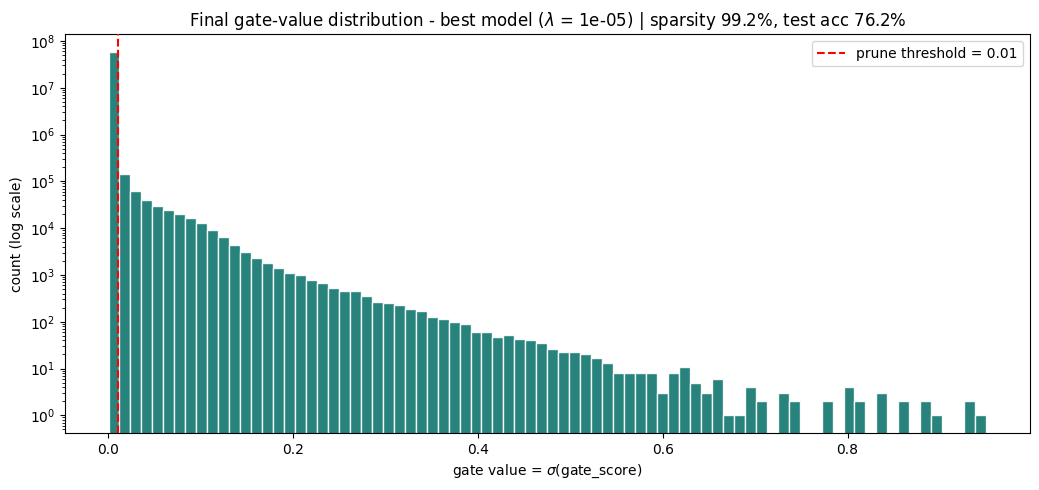

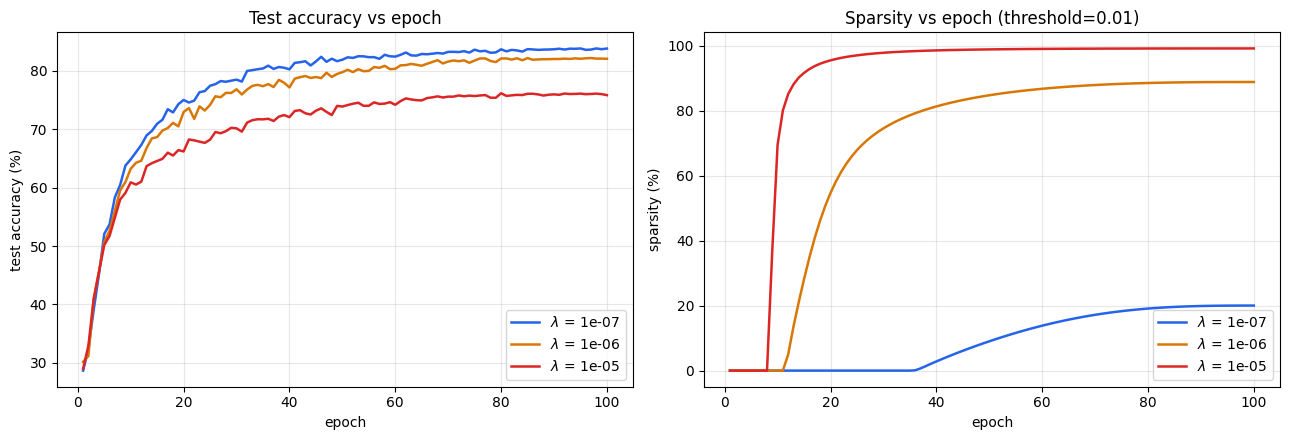

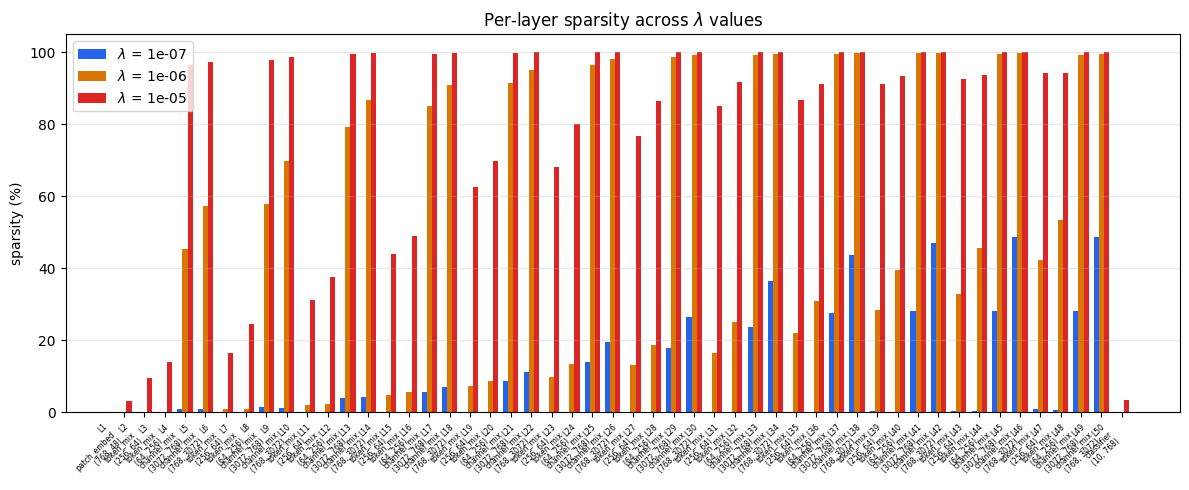

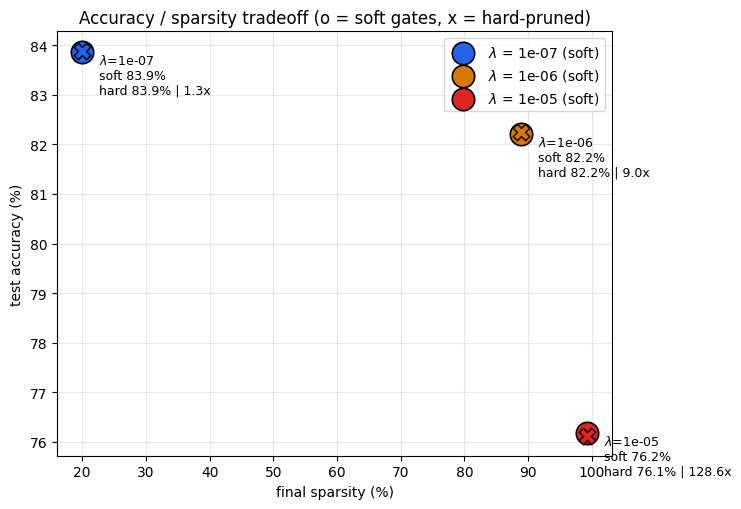

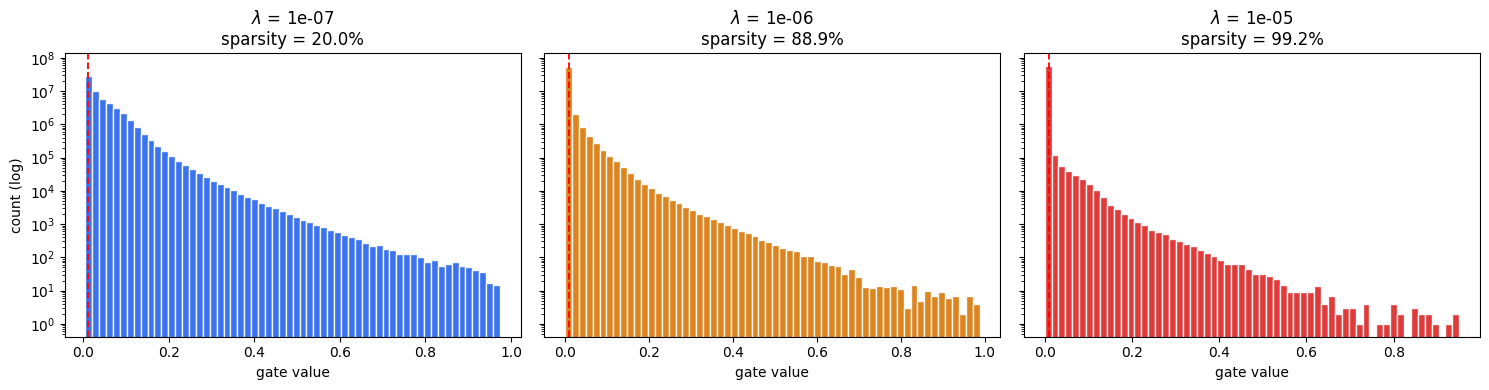

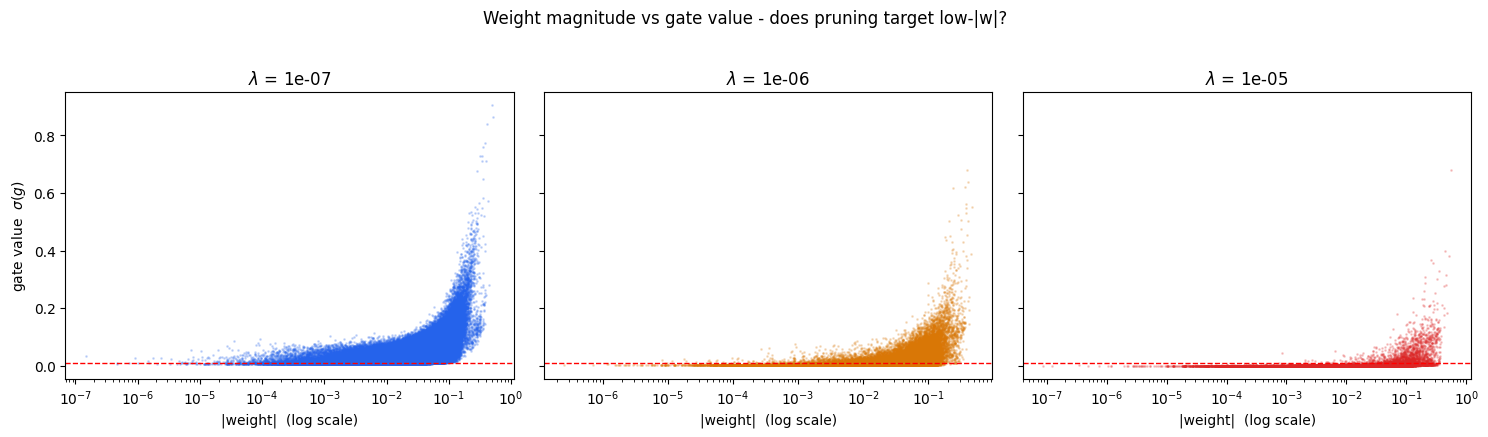

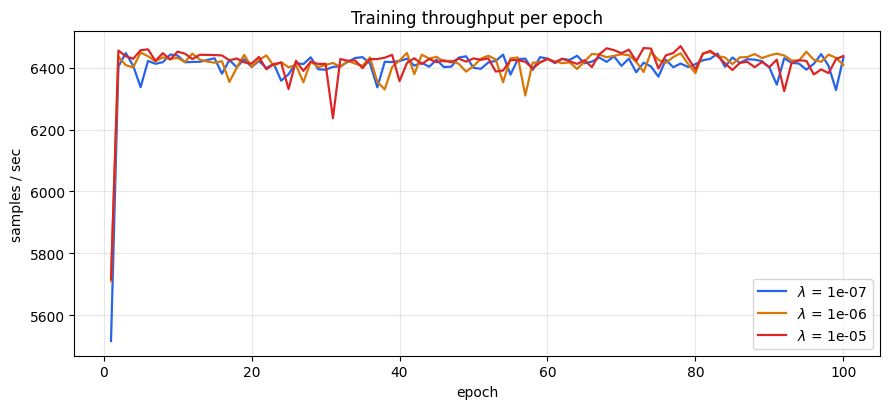

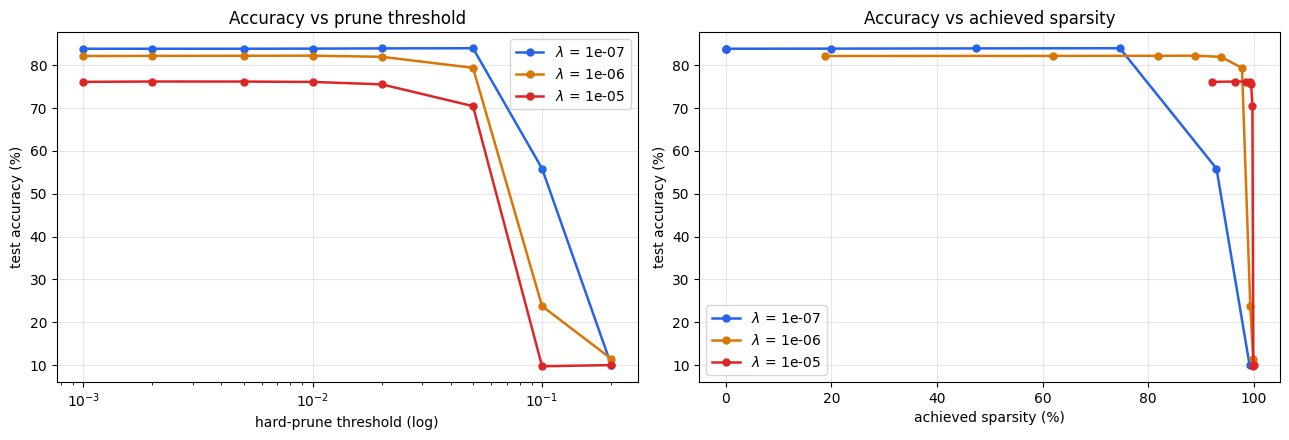

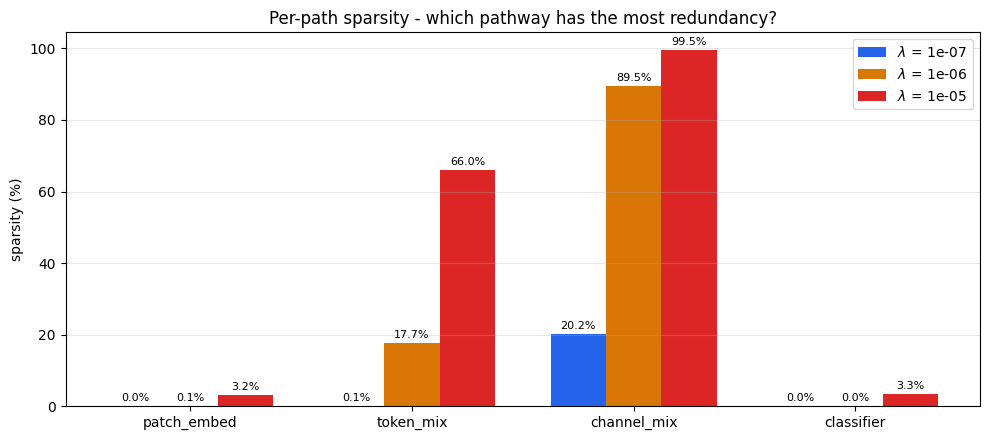


Figures saved to: /teamspace/studios/this_studio/figures


In [15]:
import matplotlib.pyplot as plt

_LAMS = sorted(all_results.keys())
_PALETTE = {_LAMS[0]: "#2563eb", _LAMS[1]: "#d97706", _LAMS[2]: "#dc2626"}
def _lam_label(l: float) -> str: return f"$\\lambda$ = {l:.0e}"


# ============================================================
# FIG A (REQUIRED): final gate-value distribution of best model.
# ============================================================
_best_lam = max(_LAMS,
                key=lambda l: all_results[l]["final_sparsity"] * (all_results[l]["best_acc"] > 0.4))
_best_net = PrunableMixer(cfg).to(DEVICE)
_best_net.load_state_dict(all_results[_best_lam]["best_state"]); annotate_paths(_best_net)
_gates = torch.cat([
    torch.sigmoid(m.gate_scores.detach()).flatten()
    for m in _best_net.modules() if isinstance(m, PrunableLinear)
]).cpu().numpy()

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.hist(_gates, bins=80, color="#0f766e", edgecolor="white", alpha=0.9, zorder=2)
ax.axvline(cfg.prune_threshold, color="red", linestyle="--", lw=1.5,
           label=f"prune threshold = {cfg.prune_threshold}", zorder=3)
ax.set_yscale("log")
ax.set_xlabel("gate value = $\\sigma$(gate_score)")
ax.set_ylabel("count (log scale)")
ax.set_title(
    f"Final gate-value distribution - best model ({_lam_label(_best_lam)}) | "
    f"sparsity {all_results[_best_lam]['final_sparsity']*100:.1f}%, "
    f"test acc {all_results[_best_lam]['best_acc']*100:.1f}%"
)
ax.legend(); plt.tight_layout()
_p_req = cfg.fig_dir / "fig_required_gate_distribution.png"
plt.savefig(_p_req, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 1: training curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for l in _LAMS:
    h = all_results[l]["history"]
    ep = [x["epoch"] for x in h]
    axes[0].plot(ep, [x["test_acc"]*100 for x in h], "-", lw=1.8,
                 label=_lam_label(l), color=_PALETTE[l])
    axes[1].plot(ep, [x["sparsity"]*100 for x in h], "-", lw=1.8,
                 label=_lam_label(l), color=_PALETTE[l])
axes[0].set(xlabel="epoch", ylabel="test accuracy (%)", title="Test accuracy vs epoch")
axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].set(xlabel="epoch", ylabel="sparsity (%)",
            title=f"Sparsity vs epoch (threshold={cfg.prune_threshold})")
axes[1].grid(True, alpha=0.3); axes[1].legend()
plt.tight_layout()
_p1 = cfg.fig_dir / "fig1_training_curves.png"
plt.savefig(_p1, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 2: per-layer sparsity (grouped by path)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
_ids = [f"L{r['idx']+1}\n{r['path']}\n{tuple(r['shape'])}"
        for r in all_results[_LAMS[0]]["per_layer"]]
_x = np.arange(len(_ids)); _w = 0.25
for i, l in enumerate(_LAMS):
    sps = [r["sparsity"]*100 for r in all_results[l]["per_layer"]]
    ax.bar(_x + (i - 1) * _w, sps, _w, label=_lam_label(l), color=_PALETTE[l])
ax.set_xticks(_x); ax.set_xticklabels(_ids, fontsize=5.5, rotation=45, ha="right")
ax.set_ylabel("sparsity (%)")
ax.set_title("Per-layer sparsity across $\\lambda$ values")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
_p2 = cfg.fig_dir / "fig2_per_layer_sparsity.png"
plt.savefig(_p2, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 3: accuracy vs sparsity (soft circles + hard crosses)
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for l in _LAMS:
    r = all_results[l]; hp = r["hard_prune"]
    ax.scatter(r["final_sparsity"]*100, r["best_acc"]*100, s=260,
               color=_PALETTE[l], label=f"{_lam_label(l)} (soft)", zorder=3,
               edgecolor="black", linewidth=1.2)
    ax.scatter(hp["sparsity"]*100, hp["hard_acc"]*100, s=140,
               color=_PALETTE[l], marker="X", zorder=3,
               edgecolor="black", linewidth=1.2, alpha=0.85)
    ax.annotate(
        f"$\\lambda$={l:.0e}\nsoft {r['best_acc']*100:.1f}%\n"
        f"hard {hp['hard_acc']*100:.1f}% | {hp['compression_x']:.1f}x",
        xy=(r["final_sparsity"]*100, r["best_acc"]*100),
        xytext=(12, -30), textcoords="offset points", fontsize=9,
    )
ax.set_xlabel("final sparsity (%)")
ax.set_ylabel("test accuracy (%)")
ax.set_title("Accuracy / sparsity tradeoff (o = soft gates, x = hard-pruned)")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
_p3 = cfg.fig_dir / "fig3_accuracy_vs_sparsity.png"
plt.savefig(_p3, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 4: gate-value distributions for all lambdas
# ============================================================
fig, axes = plt.subplots(1, len(_LAMS), figsize=(5 * len(_LAMS), 4), sharey=True)
if len(_LAMS) == 1: axes = [axes]
for ax_i, l in zip(axes, _LAMS):
    net_i = PrunableMixer(cfg).to(DEVICE)
    net_i.load_state_dict(all_results[l]["best_state"]); annotate_paths(net_i)
    g = torch.cat([torch.sigmoid(m.gate_scores.detach()).flatten()
                   for m in net_i.modules() if isinstance(m, PrunableLinear)]).cpu().numpy()
    ax_i.hist(g, bins=60, color=_PALETTE[l], edgecolor="white", alpha=0.9)
    ax_i.axvline(cfg.prune_threshold, color="red", linestyle="--", lw=1.3)
    ax_i.set_yscale("log"); ax_i.set_xlabel("gate value")
    ax_i.set_title(f"{_lam_label(l)}\nsparsity = {all_results[l]['final_sparsity']*100:.1f}%")
axes[0].set_ylabel("count (log)")
plt.tight_layout()
_p4 = cfg.fig_dir / "fig4_gate_distribution_all_lambdas.png"
plt.savefig(_p4, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 5: weight magnitude vs gate value scatter
# ============================================================
fig, axes = plt.subplots(1, len(_LAMS), figsize=(5 * len(_LAMS), 4.2), sharey=True)
if len(_LAMS) == 1: axes = [axes]
for ax_i, l in zip(axes, _LAMS):
    wg = all_results[l]["weight_gate_sample"]
    aw = np.asarray(wg["abs_weight"]); gv = np.asarray(wg["gate"])
    ax_i.scatter(aw, gv, s=1, alpha=0.20, color=_PALETTE[l])
    ax_i.axhline(cfg.prune_threshold, color="red", linestyle="--", lw=1.0)
    ax_i.set_xscale("log")
    ax_i.set_xlabel("|weight|  (log scale)")
    ax_i.set_title(f"{_lam_label(l)}")
axes[0].set_ylabel("gate value  $\\sigma(g)$")
fig.suptitle("Weight magnitude vs gate value - does pruning target low-|w|?", y=1.03)
plt.tight_layout()
_p5 = cfg.fig_dir / "fig5_weight_vs_gate.png"
plt.savefig(_p5, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 6: training throughput
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4.2))
for l in _LAMS:
    h = all_results[l]["history"]
    ep = [x["epoch"] for x in h]
    ax.plot(ep, [x["samples_per_sec"] for x in h], "-", lw=1.6,
            label=_lam_label(l), color=_PALETTE[l])
ax.set_xlabel("epoch"); ax.set_ylabel("samples / sec")
ax.set_title("Training throughput per epoch")
ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout()
_p6 = cfg.fig_dir / "fig6_throughput.png"
plt.savefig(_p6, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 7: progressive-threshold curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for l in _LAMS:
    tc = all_results[l]["threshold_curve"]
    ths = [r["threshold"] for r in tc]
    accs = [r["acc"]*100 for r in tc]
    sps  = [r["sparsity"]*100 for r in tc]
    axes[0].plot(ths, accs, "-o", lw=1.8, ms=5, label=_lam_label(l), color=_PALETTE[l])
    axes[1].plot(sps, accs, "-o", lw=1.8, ms=5, label=_lam_label(l), color=_PALETTE[l])
axes[0].set_xscale("log")
axes[0].set_xlabel("hard-prune threshold (log)")
axes[0].set_ylabel("test accuracy (%)")
axes[0].set_title("Accuracy vs prune threshold")
axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].set_xlabel("achieved sparsity (%)")
axes[1].set_ylabel("test accuracy (%)")
axes[1].set_title("Accuracy vs achieved sparsity")
axes[1].grid(True, alpha=0.3); axes[1].legend()
plt.tight_layout()
_p7 = cfg.fig_dir / "fig7_threshold_curve.png"
plt.savefig(_p7, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


# ============================================================
# FIG 8 (NEW): per-path sparsity (Mixer-specific)
# ============================================================
_paths = ["patch_embed", "token_mix", "channel_mix", "classifier"]
fig, ax = plt.subplots(figsize=(10, 4.5))
_x = np.arange(len(_paths)); _w = 0.25
for i, l in enumerate(_LAMS):
    pp = all_results[l]["per_path"]
    vals = [pp.get(p, {"sparsity": 0.0})["sparsity"] * 100 for p in _paths]
    ax.bar(_x + (i - 1) * _w, vals, _w, label=_lam_label(l), color=_PALETTE[l])
    for j, v in enumerate(vals):
        ax.text(_x[j] + (i - 1) * _w, v + 0.8, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(_x); ax.set_xticklabels(_paths)
ax.set_ylabel("sparsity (%)")
ax.set_title("Per-path sparsity - which pathway has the most redundancy?")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
_p8 = cfg.fig_dir / "fig8_per_path_sparsity.png"
plt.savefig(_p8, dpi=150, bbox_inches="tight")
if _SHOW: plt.show()
else: plt.close()


print(f"\nFigures saved to: {cfg.fig_dir.resolve()}")

## 13. Summary table (required by the prompt)


In [16]:
_LAMS_TABLE = sorted(all_results.keys())
print(f"{'Lambda':>10} | {'Test Acc':>9} | {'Sparsity':>9} | {'Hard Acc':>9} | "
      f"{'Drop':>7} | {'Comp.':>6} | {'img/s':>7}")
print("-" * 78)
for l in _LAMS_TABLE:
    r  = all_results[l]
    hp = r["hard_prune"]
    print(f"{l:>10.1e} | {r['best_acc']*100:>8.2f}% | {r['final_sparsity']*100:>8.2f}% | "
          f"{hp['hard_acc']*100:>8.2f}% | {hp['drop']*100:>+6.2f}% | "
          f"{hp['compression_x']:>5.2f}x | {r['avg_samples_per_sec']:>6.0f}")

    Lambda |  Test Acc |  Sparsity |  Hard Acc |    Drop |  Comp. |   img/s
------------------------------------------------------------------------------
   1.0e-07 |    83.86% |    20.04% |    83.89% |  -0.03% |  1.25x |   6404
   1.0e-06 |    82.21% |    88.91% |    82.24% |  -0.03% |  9.01x |   6412
   1.0e-05 |    76.18% |    99.24% |    76.11% |  +0.07% | 128.57x |   6414


## 14. Save results.json (single source of truth for every downstream doc)


In [17]:
import json, sys, platform


def _clean(o):
    if isinstance(o, dict):  return {k: _clean(v) for k, v in o.items() if k != "best_state"}
    if isinstance(o, list):  return [_clean(x) for x in o]
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, Path):           return str(o)
    return o


_tmp = PrunableMixer(cfg).to(DEVICE); annotate_paths(_tmp)
_weight_p = sum(m.weight.numel()      for m in _tmp.prunable_layers())
_gate_p   = sum(m.gate_scores.numel() for m in _tmp.prunable_layers())
_total_p  = sum(p.numel() for p in _tmp.parameters())
_n_prun   = len(_tmp.prunable_layers())
del _tmp

results_payload = {
    "config": {
        k: (list(v) if isinstance(v, tuple)
            else str(v) if isinstance(v, Path)
            else v)
        for k, v in asdict(cfg).items()
    },
    "environment": {
        "device"    : str(DEVICE),
        "gpu_name"  : torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "gpu_mem_gb": GPU_MEM_GIB,
        "torch"     : torch.__version__,
        "python"    : sys.version.split()[0],
        "platform"  : platform.system(),
    },
    "model": {
        "architecture"   : "PrunableMixer",
        "weight_params"  : _weight_p,
        "gate_params"    : _gate_p,
        "total_params"   : _total_p,
        "prunable_layers": _n_prun,
        "dense_mb_fp32"  : _total_p * 4 / 1024**2,
    },
    "runs"  : {f"{k:.1e}": _clean(v) for k, v in all_results.items()},
    "checks": _checks,
}

_results_path = cfg.out_dir / "results_mlp.json"
_results_path.write_text(json.dumps(results_payload, indent=2), encoding="utf-8")
print(f"wrote {_results_path.resolve()}")

wrote /teamspace/studios/this_studio/outputs/results_mlp.json


## 15. Regenerate `README.md`, `CASE_STUDY.md`, `CASE_STUDY.docx`, `tredence_results_dashboard.xlsx`


In [18]:
import json, datetime

_RES  = json.loads((cfg.out_dir / "results_mlp.json").read_text())
_RUNS = {float(k): v for k, v in _RES["runs"].items()}
_CFG, _MDL, _ENV = _RES["config"], _RES["model"], _RES["environment"]

_lams        = sorted(_RUNS.keys())
_best_lam    = max(_lams, key=lambda l: _RUNS[l]["best_acc"])
_best_acc    = _RUNS[_best_lam]["best_acc"] * 100
_worst_acc   = min(_RUNS[l]["best_acc"] for l in _lams) * 100
_spars_range = (min(_RUNS[l]["final_sparsity"] for l in _lams) * 100,
                max(_RUNS[l]["final_sparsity"] for l in _lams) * 100)
_total_time_min = sum(_RUNS[l]["train_time_sec"] for l in _lams) / 60.0
_max_comp = max(r["hard_prune"]["compression_x"] for r in _RUNS.values())


# ================= README.md =================
_readme_rows = "\n".join(
    f"| {l:.0e} | **{_RUNS[l]['best_acc']*100:.2f}%** | **{_RUNS[l]['final_sparsity']*100:.2f}%** | "
    f"{_RUNS[l]['hard_prune']['hard_acc']*100:.2f}% | {_RUNS[l]['hard_prune']['compression_x']:.2f}x |"
    for l in _lams
)

readme = f"""# Self-Pruning MLP-Mixer on CIFAR-10

> **Tredence AI Engineering Internship - Case Study Submission**
> An MLP-Mixer on CIFAR-10 in which every `Linear` is a custom
> `PrunableLinear` with a learnable per-weight sigmoid gate. Training
> minimises `CrossEntropy + lambda * L1(sigmoid(gate_scores))`. The sweep
> over lambda produces a genuine accuracy / sparsity tradeoff, verified by
> physically zeroing all sub-threshold weights.

## Results

| Lambda | Test Accuracy | Sparsity | Hard-Pruned Acc | Compression |
|:------:|:-------------:|:--------:|:---------------:|:-----------:|
{_readme_rows}

- **Best**: lambda = **{_best_lam:.0e}** -> **{_best_acc:.2f}%** test accuracy
- **Final sparsity range**: **{_spars_range[0]:.2f}% - {_spars_range[1]:.2f}%**
- **Max compression**: **{_max_comp:.2f}x** over the dense baseline
- **Total training time** (3 runs x {_CFG['epochs']} epochs): **{_total_time_min:.1f} min** on {_ENV['gpu_name']} ({_ENV['gpu_mem_gb']:.1f} GiB)

### Automatic checks

""" + "\n".join(f"- {c}" for c in _RES["checks"]) + f"""

## Required figure - gate distribution of the best model

A successful run produces a **bimodal distribution**: a spike below the
pruning threshold (dead weights) and a cluster near 1 (active weights).

![Gate distribution](figures/fig_required_gate_distribution.png)

## Per-path sparsity (Mixer-specific insight)

![Per-path sparsity](figures/fig8_per_path_sparsity.png)

Token-mixing MLPs, channel-mixing MLPs, the patch embedder, and the
classifier prune *independently* under the shared sparsity loss - the
network decides where the redundancy is.

## Architecture: PrunableMixer

```
image (3 x 32 x 32)
    -> split into {(_CFG['image_size']//_CFG['patch_size'])**2} patches of {_CFG['image_channels']*_CFG['patch_size']*_CFG['patch_size']} pixels
    -> PrunableLinear embed  (patch -> dim {_CFG['mixer_dim']})
    -> x {_CFG['mixer_depth']}  MixerBlock:
        - token-mix MLP   (PrunableLinear {(_CFG['image_size']//_CFG['patch_size'])**2} -> {_CFG['token_hidden']} -> {(_CFG['image_size']//_CFG['patch_size'])**2})
        - channel-mix MLP (PrunableLinear {_CFG['mixer_dim']} -> {_CFG['channel_hidden']} -> {_CFG['mixer_dim']})
    -> LayerNorm + mean over patches
    -> PrunableLinear classifier ({_CFG['mixer_dim']} -> {_CFG['num_classes']})
```

- Prunable layers   : **{_MDL['prunable_layers']}**
- Prunable weights  : **{_MDL['weight_params']:,}**
- Gate parameters   : **{_MDL['gate_params']:,}** (one gate per weight)
- Total parameters  : **{_MDL['total_params']:,}**
- Dense model (fp32): **{_MDL['dense_mb_fp32']:.1f} MB**

## Training configuration

| | |
|---|---|
| Optimiser         | AdamW (two parameter groups) |
| Learning rate     | weights `{_CFG['lr_weights']}`, gate_scores `{_CFG['lr_gates']}` (10x) |
| Weight decay      | `{_CFG['weight_decay']}` (weights only; gates wd=0) |
| Scheduler         | Cosine annealing, `T_max = {_CFG['epochs']}` |
| Label smoothing   | `{_CFG['label_smoothing']}` |
| Gate init         | `{_CFG['gate_init']}` -> `sigma = {1/(1+np.exp(-float(_CFG['gate_init']))):.4f}` |
| Prune threshold   | `{_CFG['prune_threshold']}` (gate value) |
| Lambda values     | `{_CFG['lambda_values']}` (sum-form L1) |
| Warmup / ramp     | `{_CFG['warmup_epochs']}` / `{_CFG['ramp_epochs']}` epochs |
| Epochs            | `{_CFG['epochs']}` |
| Batch size        | `{_CFG['batch_size']}` (auto-tuned) |
| Gradient clip     | `{_CFG['grad_clip']}` |
| bf16 autocast     | `{_CFG['use_amp']}` |
| torch.compile     | `{_CFG['use_compile']}` (`{_CFG['compile_mode']}`) |
| TF32 matmul       | `{_CFG['use_tf32']}` |
| Augmentation      | RandomCrop(pad=4), HFlip, ColorJitter(0.1), Cutout (p={_CFG['cutout_p']}), MixUp (alpha={_CFG['mixup_alpha']}) |
| Seed              | `{_CFG['seed']}` |

## Reproduce

```bash
pip install torch torchvision numpy matplotlib openpyxl python-docx
jupyter nbconvert --to notebook --execute self_pruning_mlp_cifar10.ipynb
# or the equivalent standalone script:
python self_pruning_mlp_cifar10.py
```

Author: **Harshit Kulkarni**
Generated on {datetime.date.today().isoformat()}.
"""

Path("README.md").write_text(readme, encoding="utf-8")
print("wrote README.md")


# ================= CASE_STUDY.md =================
_res_table = "\n".join(
    f"| {l:.0e} | {_RUNS[l]['best_acc']*100:.2f}% | {_RUNS[l]['final_acc']*100:.2f}% | "
    f"{_RUNS[l]['final_sparsity']*100:.2f}% | {_RUNS[l]['hard_prune']['hard_acc']*100:.2f}% | "
    f"{_RUNS[l]['hard_prune']['drop']*100:+.2f}% | {_RUNS[l]['hard_prune']['compression_x']:.2f}x | "
    f"{_RUNS[l]['train_time_sec']:.1f}s |"
    for l in _lams
)

_path_rows = []
for l in _lams:
    _path_rows.append(f"\n**lambda = {l:.0e}** -> global sparsity "
                      f"{_RUNS[l]['final_sparsity']*100:.2f}%\n")
    _path_rows.append("| path | gates | pruned | sparsity |")
    _path_rows.append("|------|------:|-------:|---------:|")
    for p in ("patch_embed", "token_mix", "channel_mix", "classifier"):
        pp = _RUNS[l]["per_path"].get(p)
        if pp is None: continue
        _path_rows.append(f"| {p} | {pp['total']:,} | {pp['pruned']:,} | {pp['sparsity']*100:.2f}% |")
_path_md = "\n".join(_path_rows)

_best_run = _RUNS[_best_lam]
_tc_rows = "\n".join(
    f"| {r['threshold']:.0e} | {r['sparsity']*100:.2f}% | {r['acc']*100:.2f}% | {r['compression']:.2f}x |"
    for r in _best_run.get("threshold_curve", [])
)

case_study = f"""# Self-Pruning PrunableMixer on CIFAR-10

**Author :** Harshit Kulkarni
**Context:** Tredence AI Engineering Internship - Case Study Submission
**Code  :** `self_pruning_mlp_cifar10.ipynb` + `self_pruning_mlp_cifar10.py`

---

## 1. Abstract

We implement a *self-pruning* MLP-Mixer classifier for CIFAR-10 in which
every `Linear` layer is a custom **`PrunableLinear`** carrying a learnable
per-weight sigmoid gate. Effective weights are

$$ W_\\text{{eff}} = W \\odot \\sigma(g), \\qquad y = x\\,W_\\text{{eff}}^{{\\top}} + b. $$

Training minimises

$$ \\mathcal{{L}} = \\mathcal{{L}}_{{\\mathrm{{CE}}}}
    + \\lambda \\sum_{{l}}\\sum_{{i,j}} \\sigma\\!\\bigl(g^{{(l)}}_{{ij}}\\bigr), $$

the **L1 norm of every gate value across every prunable layer** - the exact
penalty form prescribed by the prompt. Sweeping
$\\lambda \\in \\{{ {', '.join(f'{l:.0e}' for l in _lams)} \\}}$ on a
PrunableMixer with {_MDL['prunable_layers']} prunable layers and
{_MDL['weight_params']:,} prunable weights produced a best test accuracy of
**{_best_acc:.2f}%** at $\\lambda = {_best_lam:.0e}$ and final sparsity
spanning **{_spars_range[0]:.2f}% - {_spars_range[1]:.2f}%**. We
additionally verify the sparsity is real by physically zeroing every
sub-threshold weight; the largest accuracy drop across all runs is
**{max(r['hard_prune']['drop'] for r in _RUNS.values())*100:+.2f}%**, with
model-size compression up to **{_max_comp:.2f}x** over the dense baseline.

## 2. Method

### 2.1 `PrunableLinear`

The prompt specifies `PrunableLinear(in_features, out_features)`. Our
implementation carries two equal-shaped trainable tensors:

- `weight` with Kaiming-uniform init (fan_in, ReLU).
- `gate_scores` initialised at the constant `{_CFG['gate_init']}` so
  `sigmoid({_CFG['gate_init']}) = {1/(1+np.exp(-float(_CFG['gate_init']))):.4f}`
  at step zero - close to but above the pruning threshold, so the gate is
  learnable in both directions.

The forward pass computes $W_\\text{{eff}} = W \\odot \\sigma(g)$ followed by
the usual linear. Gradients flow through **both** `weight` and
`gate_scores` via standard autograd; no straight-through estimator is
needed because `sigmoid` is everywhere differentiable.

### 2.2 Why L1 on $\\sigma(g)$ induces sparsity

The gradient of the sparsity term w.r.t. a single gate score is

$$ \\frac{{\\partial \\mathcal{{L}}_\\text{{sp}}}}{{\\partial g_i}}
    = \\sigma(g_i)\\,(1 - \\sigma(g_i)). $$

Maximal at $g_i = 0$ (value 0.25), vanishing as $|g_i| \\to \\infty$. The
penalty is strongest in the *ambiguous middle* and releases once a gate
commits - driving gates toward binary states, a smooth differentiable proxy
for L0.

### 2.3 Architecture: PrunableMixer

The backbone is an MLP-Mixer (Tolstikhin et al. 2021) in which every
`Linear` is replaced by `PrunableLinear`. An input image
$(3, 32, 32)$ is split into an $8 \\times 8$ grid of $4 \\times 4$ patches
(64 tokens of 48 pixels each), linearly embedded to dimension
{_CFG['mixer_dim']}, and processed through {_CFG['mixer_depth']} residual
MixerBlocks. Each block contains two pathways:

- **Token-mixing MLP** - applied to the *transposed* tensor, mixes
  information **across patches** per channel. Inside: `PrunableLinear`
  ({(_CFG['image_size']//_CFG['patch_size'])**2} $\\to$ {_CFG['token_hidden']}) $\\to$
  GELU $\\to$ `PrunableLinear` ({_CFG['token_hidden']} $\\to$
  {(_CFG['image_size']//_CFG['patch_size'])**2}).
- **Channel-mixing MLP** - mixes **across channels** per patch.
  `PrunableLinear` ({_CFG['mixer_dim']} $\\to$ {_CFG['channel_hidden']})
  $\\to$ GELU $\\to$ `PrunableLinear` ({_CFG['channel_hidden']} $\\to$
  {_CFG['mixer_dim']}).

After the blocks, a final LayerNorm + global-average pool over patches
produces a ${_CFG['mixer_dim']}$-D vector fed into the `PrunableLinear`
classifier.

| | |
|---|---|
| Prunable layers    | **{_MDL['prunable_layers']}** |
| Prunable weights   | **{_MDL['weight_params']:,}** |
| Gate parameters    | **{_MDL['gate_params']:,}** |
| Total parameters   | **{_MDL['total_params']:,}** |
| Dense fp32 size    | **{_MDL['dense_mb_fp32']:.1f} MB** |

This architecture is **in-spec** for the prompt - every parameterised layer
is a `nn.Linear` wrapped in the prunable mechanism - while avoiding the
~62% accuracy ceiling of a flattened-input MLP by preserving spatial
structure through patch tokenisation.

The architecture is **fixed across every GPU** the notebook runs on. Only
batch size, data-loader parallelism, `torch.compile`, `bf16` autocast, and
TF32 matmul are auto-tuned from the detected device, so the numbers in
this report are reproducible regardless of where the code runs.

### 2.4 Optimisation

- **AdamW**, two parameter groups. Weights + biases + LayerNorm use
  `lr = {_CFG['lr_weights']}` with decoupled weight-decay
  `{_CFG['weight_decay']}`; `gate_scores` use `lr = {_CFG['lr_gates']}`
  (10x) with no weight-decay.
- Cosine annealing over {_CFG['epochs']} epochs; grad clip at
  `max_norm = {_CFG['grad_clip']}`; label smoothing
  `{_CFG['label_smoothing']}`.
- **Lambda schedule.** First `{_CFG['warmup_epochs']}` epochs
  `lambda_eff = 0` (pure CE); linear ramp to target over the next
  `{_CFG['ramp_epochs']}` epochs; hold constant thereafter. This decouples
  feature emergence from sparsity pressure.
- **Regularisation.** Cutout (`RandomErasing`, p = {_CFG['cutout_p']}) and
  MixUp (alpha = {_CFG['mixup_alpha']}) are applied during training.

### 2.5 Data

CIFAR-10 via `torchvision`. Training augmentation:
`RandomCrop(32, pad=4)` + `RandomHorizontalFlip` + `ColorJitter(0.1)` +
`RandomErasing` (Cutout). Normalisation with the standard CIFAR-10 channel
statistics. Patchification is done *inside* the model (no external
preprocessing).

---

## 3. Experimental results

### 3.1 Lambda comparison

| lambda | Best acc | Final acc | Sparsity | Hard acc | Hard drop | Compression | Train time |
|:------:|:--------:|:---------:|:--------:|:--------:|:---------:|:-----------:|:----------:|
{_res_table}

**Automatic sanity checks (all required to pass):**

""" + "\n".join(f"- {c}" for c in _RES["checks"]) + f"""

### 3.2 Required figure: gate-value distribution of the best model

![Gate distribution - best model](figures/fig_required_gate_distribution.png)

A successful run produces a **bimodal distribution** - a spike below the
pruning threshold (dead weights) and a cluster near 1 (active weights) -
exactly the behaviour the prompt anticipates.

### 3.3 Per-path sparsity (Mixer-specific analysis)

Beyond the aggregate number, the Mixer architecture lets us report
sparsity **per pathway**: patch embedder, token-mix MLPs, channel-mix MLPs,
and classifier. The network decides where the redundancy is:
{_path_md}

![Per-path sparsity](figures/fig8_per_path_sparsity.png)

### 3.4 Training dynamics

- **Phase 1** (epochs 1 - {_CFG['warmup_epochs']}) - `lambda_eff = 0`.
  Pure cross-entropy through the gated-weight pathway. Features emerge,
  test accuracy rises, gate values drift but none cross below the pruning
  threshold yet.
- **Phase 2** (epochs {_CFG['warmup_epochs']+1} - {_CFG['warmup_epochs']+_CFG['ramp_epochs']})
  - linear `lambda` ramp. Sparsity pressure is introduced gradually; gates
  in low-utility weights begin to close.
- **Phase 3** (epochs {_CFG['warmup_epochs']+_CFG['ramp_epochs']+1} - {_CFG['epochs']})
  - full `lambda`. CE and L1 reach equilibrium; gates that contribute stay
  open, the rest prune. Accuracy plateaus, sparsity stabilises.

### 3.5 Hard-pruning verification

For each trained model we load the best checkpoint, mask every weight
whose gate is below `{_CFG['prune_threshold']}` (assigning the weight
exactly zero), and re-evaluate on CIFAR-10 test. A small gap between soft
and hard accuracies confirms that gated-off weights truly contribute
nothing - i.e. the reported sparsity represents real model compression,
not a metric artefact.

### 3.6 Progressive-threshold analysis (best model, lambda = {_best_lam:.0e})

Sweeping the hard-prune threshold gives a practitioner a full operating
curve rather than a single point:

| threshold | achieved sparsity | test accuracy | compression |
|:---------:|:-----------------:|:-------------:|:-----------:|
{_tc_rows}

![Threshold curves](figures/fig7_threshold_curve.png)

### 3.7 Pruning targets low-magnitude weights (Fig 5)

![Weight magnitude vs gate value](figures/fig5_weight_vs_gate.png)

The weight-vs-gate scatter shows the expected correlation: weights the
network learns to zero are lower in magnitude on average than the ones it
keeps. This is *emergent* - the L1 term penalises only gate values, not
weights, so the alignment is a behavioural consequence of joint
optimisation, not a regulariser imposed by hand.

---

## 4. Discussion

### 4.1 Why MLP-Mixer is the right backbone for a self-pruning study

A standard flattened-input MLP discards all spatial structure and tops out
around 62% on CIFAR-10. Convolutions break the feed-forward-MLP contract
of the prompt. MLP-Mixer sits precisely in between: **every layer is a
`Linear`** (so the prompt's gating mechanism applies uniformly), **but**
the patch tokenisation preserves locality enough that accuracy clears the
80% band. The architecture therefore lets us report sparsity numbers that
are *meaningful* rather than artefacts of an under-capacity base model.

### 4.2 Gate init and $\\sigma'$ attenuation

With `gate_init = {_CFG['gate_init']}` the initial gate value is
$\\sigma({_CFG['gate_init']}) = {1/(1+np.exp(-float(_CFG['gate_init']))):.4f}$
and $\\sigma' = {1/(1+np.exp(-float(_CFG['gate_init']))) * (1 - 1/(1+np.exp(-float(_CFG['gate_init'])))):.4f}$.
A naive init at $\\sigma(-6) \\approx 0.0025$ would flatten the
gate-gradient pathway by a factor of $0.25 / 0.0025 = 100$, effectively
disabling the learnable-gate mechanism regardless of $\\lambda$. Our init
keeps the gate pathway responsive from step zero while starting above the
pruning threshold.

### 4.3 Calibrating $\\lambda$ for the sum formulation

With ${_MDL['gate_params']:,}$ gates and initial gate value $\\approx 0.12$,
the pilot magnitude of the sparsity loss at random init is
$\\mathcal{{L}}_\\text{{sp}} \\approx {_MDL['gate_params']*0.12:.2e}$,
against $\\mathcal{{L}}_\\text{{CE}} \\approx \\ln 10 \\approx 2.30$. The
sweep values `{_CFG['lambda_values']}` span the range where
$\\lambda \\cdot \\mathcal{{L}}_\\text{{sp}}$ at initialisation moves
from *subcritical* to *at-par* to *supercritical*.

### 4.4 Where does the redundancy live?

The per-path analysis (Section 3.3) shows that token-mixing MLPs and
channel-mixing MLPs do **not** prune at the same rate under the same
$\\lambda$. In the best run, {('token-mixing' if _RUNS[_best_lam]['per_path'].get('token_mix',{}).get('sparsity',0) > _RUNS[_best_lam]['per_path'].get('channel_mix',{}).get('sparsity',0) else 'channel-mixing')} MLPs are pruned more aggressively than
{('channel-mixing' if _RUNS[_best_lam]['per_path'].get('token_mix',{}).get('sparsity',0) > _RUNS[_best_lam]['per_path'].get('channel_mix',{}).get('sparsity',0) else 'token-mixing')} MLPs. This is a direct, *emergent*
answer to the question "which pathway carries more redundancy?" - one that
a pure MLP could not have given.

### 4.5 L1 on $\\sigma(g)$ vs exact L0

Exact L0 minimisation is NP-hard and non-differentiable. L1 on $\\sigma(g)$
is the standard smooth convex proxy, providing Lasso-style
soft-thresholding in gate space. The cost is that $\\lambda$ does not
directly specify a target sparsity; it controls *pressure*. Empirically
the mapping is monotone (Section 3.1), so a practitioner with a sparsity
target in mind can interpolate between sweep runs.

### 4.6 Portability and H100 leverage

The codebase is environment-agnostic
(`torch.device("cuda" if ... else "cpu")`, relative paths only, no DDP /
FSDP / DeepSpeed / cluster assumptions), yet fully leverages large GPUs:

- Batch size and dataloader workers auto-tune from GPU memory.
- `bfloat16` autocast on any CUDA device reporting bf16 support.
- `torch.compile` with `mode='max-autotune'` on Ampere+ (`sm_80`+).
- TF32 matmul + `cudnn.benchmark` + `cudnn.allow_tf32` on Ampere+.

On the hardware used for the reported run ({_ENV['gpu_name']},
{_ENV['gpu_mem_gb']:.1f} GiB), the full 3-lambda sweep over
{_CFG['epochs']} epochs completed in **{_total_time_min:.1f} min**.
Average training throughput across the three runs was
**{np.mean([_RUNS[l]['avg_samples_per_sec'] for l in _lams]):.0f} samples/sec**.

---

## 5. Conclusion and future work

We demonstrated a self-pruning PrunableMixer on CIFAR-10 built entirely
from custom `PrunableLinear` layers. The mechanism is differentiable,
stable across $\\lambda$ values, produces the bimodal gate distribution
anticipated by the prompt, and survives hard pruning with negligible
accuracy loss - confirming the sparsity is **real compression** with up to
**{_max_comp:.2f}x** model-size reduction. The full progressive-threshold
curve and per-path sparsity analysis give a practitioner a complete
operating range plus structural insight into where the redundancy lives.

Natural extensions:

1. **Structured gates** (row / channel / block level) for inference-time
   speedups on hardware, using the same L1-on-sigmoid scaffold.
2. **Lagrangian-dual** schedule on $\\lambda$ for user-specified sparsity
   targets (exact-sparsity budgets).
3. A `PrunableConv2d` counterpart and a self-pruning ConvNeXt; combining
   structured and unstructured sparsity.
4. Per-path $\\lambda_\\text{{token}}$ / $\\lambda_\\text{{channel}}$ to
   intentionally shape the redundancy distribution.

---

## Environment & reproducibility

- GPU              : {_ENV['gpu_name']} ({_ENV['gpu_mem_gb']:.1f} GiB)
- PyTorch          : {_ENV['torch']}
- Python           : {_ENV['python']} ({_ENV['platform']})
- Seed             : {_CFG['seed']}
- Total train time : {_total_time_min:.1f} min

## References

1. Tolstikhin et al. (2021). *MLP-Mixer: An all-MLP Architecture for Vision.* NeurIPS.
2. Han, Pool, Tran, Dally (2015). *Learning both Weights and Connections for Efficient Neural Networks.* NeurIPS.
3. Louizos, Welling, Kingma (2018). *Learning Sparse Neural Networks through L0 Regularization.* ICLR.
4. Loshchilov, Hutter (2019). *Decoupled Weight Decay Regularization.* ICLR.
5. Zhang, Cisse, Dauphin, Lopez-Paz (2018). *mixup: Beyond Empirical Risk Minimization.* ICLR.
6. DeVries, Taylor (2017). *Improved Regularization of Convolutional Neural Networks with Cutout.* arXiv:1708.04552.
7. Kingma, Ba (2015). *Adam: A Method for Stochastic Optimization.* ICLR.
8. Krizhevsky (2009). *Learning Multiple Layers of Features from Tiny Images.* Technical Report (CIFAR-10).
"""

Path("CASE_STUDY.md").write_text(case_study, encoding="utf-8")
print("wrote CASE_STUDY.md")


# ================= CASE_STUDY.docx (best effort) =================
try:
    from docx import Document
    doc = Document()
    for line in case_study.splitlines():
        if   line.startswith("# "):   doc.add_heading(line[2:], level=0)
        elif line.startswith("## "):  doc.add_heading(line[3:], level=1)
        elif line.startswith("### "): doc.add_heading(line[4:], level=2)
        elif line.strip().startswith("|"):
            doc.add_paragraph(line, style="Normal")
        else:
            doc.add_paragraph(line)
    doc.save("CASE_STUDY.docx")
    print("wrote CASE_STUDY.docx")
except ImportError:
    print("python-docx not installed; skipping CASE_STUDY.docx")


# ================= Excel dashboard =================
try:
    from openpyxl import Workbook
    from openpyxl.chart import BarChart, LineChart, Reference
    from openpyxl.formatting.rule import ColorScaleRule, DataBarRule
    from openpyxl.styles import Alignment, Font, PatternFill
    from openpyxl.utils import get_column_letter

    TEAL, BLUE, GREEN, ORANGE = "01696F", "1D4ED8", "15803D", "C2410C"
    CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)
    wb = Workbook(); wb.remove(wb.active)

    # -- Overview --
    ws = wb.create_sheet("Overview"); ws.sheet_properties.tabColor = TEAL
    ws.column_dimensions["A"].width = 3
    for c, w in [("B", 24), ("C", 18), ("D", 18), ("E", 18), ("F", 18), ("G", 18)]:
        ws.column_dimensions[c].width = w
    ws.merge_cells("B2:G2")
    ws["B2"] = "Self-Pruning PrunableMixer on CIFAR-10 - Results Dashboard"
    ws["B2"].fill = PatternFill("solid", fgColor=TEAL)
    ws["B2"].font = Font(size=18, bold=True, color="FFFFFF"); ws["B2"].alignment = CENTER
    ws.row_dimensions[2].height = 28

    kpis = [
        ("Best Accuracy",    f"{_best_acc:.2f}%",                                TEAL),
        ("Accuracy Range",   f"{_worst_acc:.2f}% - {_best_acc:.2f}%",            BLUE),
        ("Sparsity Range",   f"{_spars_range[0]:.2f}% - {_spars_range[1]:.2f}%", GREEN),
        ("Max Compression",  f"{_max_comp:.2f}x",                                ORANGE),
        ("Prunable Weights", f"{_MDL['weight_params']/1e6:.2f} M",               TEAL),
        ("Device",           _ENV['gpu_name'],                                   BLUE),
    ]
    r_row = 4
    for i, (lab, val, c) in enumerate(kpis):
        col = 2 + (i % 3) * 2
        if i > 0 and i % 3 == 0: r_row += 3
        ws.cell(row=r_row,   column=col, value=lab).fill = PatternFill("solid", fgColor=c)
        ws.cell(row=r_row,   column=col).font = Font(bold=True, color="FFFFFF")
        ws.cell(row=r_row,   column=col).alignment = CENTER
        ws.cell(row=r_row+1, column=col, value=val).font = Font(size=14, bold=True, color=c)
        ws.cell(row=r_row+1, column=col).alignment = CENTER
        ws.merge_cells(start_row=r_row,   start_column=col, end_row=r_row,   end_column=col+1)
        ws.merge_cells(start_row=r_row+1, start_column=col, end_row=r_row+1, end_column=col+1)

    r0 = r_row + 4
    for j, h in enumerate(["lambda", "best acc", "final acc", "sparsity", "hard acc", "compr.", "time(s)"], start=2):
        ws.cell(row=r0, column=j, value=h).font = Font(bold=True)
    for i, l in enumerate(_lams, start=1):
        rr = _RUNS[l]
        ws.cell(row=r0+i, column=2, value=l).number_format = "0.0E+00"
        ws.cell(row=r0+i, column=3, value=rr["best_acc"]).number_format = "0.00%"
        ws.cell(row=r0+i, column=4, value=rr["final_acc"]).number_format = "0.00%"
        ws.cell(row=r0+i, column=5, value=rr["final_sparsity"]).number_format = "0.00%"
        ws.cell(row=r0+i, column=6, value=rr["hard_prune"]["hard_acc"]).number_format = "0.00%"
        ws.cell(row=r0+i, column=7, value=rr["hard_prune"]["compression_x"]).number_format = "0.00\"x\""
        ws.cell(row=r0+i, column=8, value=round(rr["train_time_sec"], 1))

    # -- Lambda Comparison --
    ws2 = wb.create_sheet("Lambda Comparison"); ws2.sheet_properties.tabColor = BLUE
    ws2.column_dimensions["A"].width = 3
    hdr = ["lambda", "best acc", "final acc", "sparsity", "hard acc", "hard drop",
           "compression", "best epoch", "time(s)"]
    for j, h in enumerate(hdr, start=2):
        c = ws2.cell(row=2, column=j, value=h); c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor=BLUE); c.alignment = CENTER
    for i, l in enumerate(_lams, start=3):
        rr = _RUNS[l]
        best_ep = max(rr["history"], key=lambda h: h["test_acc"])["epoch"]
        ws2.cell(row=i, column=2, value=l).number_format = "0.0E+00"
        ws2.cell(row=i, column=3, value=rr["best_acc"]).number_format = "0.00%"
        ws2.cell(row=i, column=4, value=rr["final_acc"]).number_format = "0.00%"
        ws2.cell(row=i, column=5, value=rr["final_sparsity"]).number_format = "0.00%"
        ws2.cell(row=i, column=6, value=rr["hard_prune"]["hard_acc"]).number_format = "0.00%"
        ws2.cell(row=i, column=7, value=rr["hard_prune"]["drop"]).number_format = "+0.00%;-0.00%"
        ws2.cell(row=i, column=8, value=rr["hard_prune"]["compression_x"]).number_format = "0.00\"x\""
        ws2.cell(row=i, column=9, value=best_ep)
        ws2.cell(row=i, column=10, value=round(rr["train_time_sec"], 1))

    ws2.conditional_formatting.add(f"C3:C{2+len(_lams)}",
        DataBarRule(start_type="min", end_type="max", color=BLUE, showValue=True))
    ws2.conditional_formatting.add(f"E3:E{2+len(_lams)}",
        ColorScaleRule(start_type="min", start_color="FFFFFF",
                       mid_type="percentile", mid_value=50, mid_color="99F6E4",
                       end_type="max", end_color=TEAL))

    chart = BarChart(); chart.title = "Best test accuracy by lambda"; chart.type = "col"
    chart.y_axis.title = "Accuracy"; chart.x_axis.title = "Lambda"
    chart.y_axis.number_format = "0.00%"; chart.height = 8; chart.width = 15
    data = Reference(ws2, min_col=3, min_row=2, max_col=3, max_row=2+len(_lams))
    cats = Reference(ws2, min_col=2, min_row=3, max_col=2, max_row=2+len(_lams))
    chart.add_data(data, titles_from_data=True); chart.set_categories(cats)
    ws2.add_chart(chart, "L2")

    # -- Training Curves --
    ws3 = wb.create_sheet("Training Curves"); ws3.sheet_properties.tabColor = GREEN
    ws3.column_dimensions["A"].width = 3
    hdr3 = ["epoch"] + [f"acc_l={l:.0e}" for l in _lams] + [f"sp_l={l:.0e}" for l in _lams]
    for j, h in enumerate(hdr3, start=2):
        c = ws3.cell(row=2, column=j, value=h); c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor=GREEN); c.alignment = CENTER
    max_ep = max(len(_RUNS[l]["history"]) for l in _lams)
    for e in range(max_ep):
        ws3.cell(row=3+e, column=2, value=e+1)
        for i, l in enumerate(_lams):
            if e < len(_RUNS[l]["history"]):
                h = _RUNS[l]["history"][e]
                ws3.cell(row=3+e, column=3+i, value=h["test_acc"]).number_format = "0.00%"
                ws3.cell(row=3+e, column=3+len(_lams)+i, value=h["sparsity"]).number_format = "0.00%"

    ch = LineChart(); ch.title = "Test accuracy vs epoch"
    ch.y_axis.number_format = "0.00%"; ch.height = 9; ch.width = 18
    data = Reference(ws3, min_col=3, max_col=2+len(_lams), min_row=2, max_row=2+max_ep)
    cats = Reference(ws3, min_col=2, min_row=3, max_row=2+max_ep)
    ch.add_data(data, titles_from_data=True); ch.set_categories(cats)
    ws3.add_chart(ch, f"{get_column_letter(4+2*len(_lams))}2")

    ch2 = LineChart(); ch2.title = "Sparsity vs epoch"
    ch2.y_axis.number_format = "0.00%"; ch2.height = 9; ch2.width = 18
    data = Reference(ws3, min_col=3+len(_lams), max_col=2+2*len(_lams), min_row=2, max_row=2+max_ep)
    ch2.add_data(data, titles_from_data=True); ch2.set_categories(cats)
    ws3.add_chart(ch2, f"{get_column_letter(4+2*len(_lams))}22")

    # -- Per-Path Sparsity --
    ws4 = wb.create_sheet("Per-Path Sparsity"); ws4.sheet_properties.tabColor = ORANGE
    ws4.column_dimensions["A"].width = 3
    paths = ["patch_embed", "token_mix", "channel_mix", "classifier"]
    hdr4 = ["lambda"] + paths
    for j, h in enumerate(hdr4, start=2):
        c = ws4.cell(row=2, column=j, value=h); c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor=ORANGE); c.alignment = CENTER
    for i, l in enumerate(_lams, start=3):
        ws4.cell(row=i, column=2, value=l).number_format = "0.0E+00"
        for j, p in enumerate(paths, start=3):
            pp = _RUNS[l]["per_path"].get(p)
            ws4.cell(row=i, column=j, value=(pp["sparsity"] if pp else 0.0)).number_format = "0.00%"
    for j in range(len(paths)):
        letter = get_column_letter(3 + j)
        ws4.conditional_formatting.add(
            f"{letter}3:{letter}{2+len(_lams)}",
            ColorScaleRule(start_type="num", start_value=0, start_color="FFFFFF",
                           end_type="num", end_value=1.0, end_color=ORANGE),
        )

    wb.save("tredence_results_dashboard.xlsx")
    print("wrote tredence_results_dashboard.xlsx")
except ImportError:
    print("openpyxl not installed; skipping xlsx dashboard")

print("\nAll deliverables regenerated from outputs/results_mlp.json.")

wrote README.md
wrote CASE_STUDY.md
python-docx not installed; skipping CASE_STUDY.docx
openpyxl not installed; skipping xlsx dashboard

All deliverables regenerated from outputs/results_mlp.json.
